# Bagian 1 — Import Library

Tahap ini melakukan proses import library yang digunakan pada penelitian. Library digunakan untuk proses pengolahan data, visualisasi data, pemodelan *time series*, dan evaluasi model *forecasting* menggunakan metode ARIMA dan Prophet.

In [2]:
# =========================================
# BAGIAN 1
# IMPORT LIBRARY
# =========================================

# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi data
import matplotlib.pyplot as plt

# Model ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Uji stasioneritas
from statsmodels.tsa.stattools import adfuller

# Visualisasi ACF dan PACF
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

# Model Prophet
from prophet import Prophet

# Evaluasi model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Menghilangkan warning
import warnings
warnings.filterwarnings("ignore")

print("Import library berhasil")

Import library berhasil


# Bagian 2 — Load Dataset

Tahap ini melakukan proses pemuatan dataset hasil *preprocessing* yang telah dibuat pada tahap sebelumnya. Dataset yang digunakan merupakan hasil pengambilan dan pengolahan data prakiraan cuaca BMKG yang telah disimpan dalam format *.csv*. Dataset tersebut selanjutnya digunakan pada proses pemodelan *forecasting* menggunakan metode ARIMA dan Prophet.

In [3]:
# =========================================
# BAGIAN 2
# LOAD DATASET
# =========================================

# Membaca dataset hasil preprocessing
df_cuaca = pd.read_csv(
    "dataset_bmkg.csv"
)

# Menampilkan jumlah data
print(
    "Jumlah baris :",
    df_cuaca.shape[0]
)

print(
    "Jumlah kolom :",
    df_cuaca.shape[1]
)

# Menampilkan informasi dataset
print("\nInformasi Dataset:")
df_cuaca.info()

# Menampilkan 5 data pertama
print("\n5 Data Pertama:")
display(
    df_cuaca.head()
)

# Menampilkan 5 data terakhir
print("\n5 Data Terakhir:")
display(
    df_cuaca.tail()
)

Jumlah baris : 532
Jumlah kolom : 7

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         532 non-null    object 
 1   wilayah          532 non-null    object 
 2   adm4             532 non-null    object 
 3   suhu             532 non-null    int64  
 4   kelembapan       532 non-null    int64  
 5   curah_hujan      532 non-null    float64
 6   kecepatan_angin  532 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 29.2+ KB

5 Data Pertama:


,datetime,wilayah,adm4,suhu,kelembapan,curah_hujan,kecepatan_angin
0,2026-05-24 00:00:00,Babakan,36.03.20.1011,24,96,0.0,5.6
1,2026-05-24 03:00:00,Babakan,36.03.20.1011,24,98,0.0,3.2
2,2026-05-24 06:00:00,Babakan,36.03.20.1011,26,98,0.0,5.0
3,2026-05-24 09:00:00,Babakan,36.03.20.1011,29,73,0.0,4.3
4,2026-05-24 12:00:00,Babakan,36.03.20.1011,32,85,3.8,7.5



5 Data Terakhir:


,datetime,wilayah,adm4,suhu,kelembapan,curah_hujan,kecepatan_angin
527,2026-05-25 18:00:00,Tigaraksa,36.03.03.1001,26,93,0.1,1.7
528,2026-05-25 21:00:00,Tigaraksa,36.03.03.1001,25,97,0.0,2.1
529,2026-05-26 00:00:00,Tigaraksa,36.03.03.1001,24,97,0.0,6.5
530,2026-05-26 03:00:00,Tigaraksa,36.03.03.1001,24,96,0.0,3.7
531,2026-05-26 06:00:00,Tigaraksa,36.03.03.1001,24,96,0.0,2.2


In [4]:
# =========================================
# PEMERIKSAAN DUPLIKASI DATA
# =========================================

# Menghitung jumlah data duplikat
jumlah_duplikasi = df_cuaca.duplicated().sum()

print(
    "Jumlah data duplikat :",
    jumlah_duplikasi
)

# Menghapus data duplikat apabila ditemukan
if jumlah_duplikasi > 0:
    df_cuaca = df_cuaca.drop_duplicates()
    df_cuaca = df_cuaca.reset_index(drop=True)
    print("Data duplikat berhasil dihapus")
else:
    print("Tidak terdapat data duplikat")

Jumlah data duplikat : 0
Tidak terdapat data duplikat


# Bagian 3 — Pemilihan Variabel Forecasting

Tahap ini melakukan pemilihan variabel target yang digunakan pada proses *forecasting*. Penelitian ini menggunakan variabel suhu sebagai target utama prediksi karena suhu memiliki pola data yang relatif kontinu dan lebih stabil dibandingkan parameter cuaca lainnya. Variabel kelembapan, curah hujan, dan kecepatan angin digunakan sebagai variabel pendukung pada tahap eksplorasi data dan interpretasi hasil penelitian.

In [5]:
# =========================================
# BAGIAN 3
# PEMILIHAN VARIABEL FORECASTING
# =========================================

# Menentukan variabel target
target = "suhu"

print(
    "Variabel target forecasting :",
    target
)

Variabel target forecasting : suhu


# Bagian 4 — Filter Wilayah Penelitian

Tahap ini melakukan proses pemilihan wilayah penelitian yang digunakan pada tahap awal pemodelan *forecasting*. Penelitian ini menggunakan 28 wilayah kelurahan di Kabupaten Tangerang. Namun, proses pengujian model dilakukan terlebih dahulu pada satu wilayah penelitian, yaitu Kelurahan Mauk Timur. Pemilihan satu wilayah pada tahap awal bertujuan untuk mempermudah proses pengujian model, identifikasi kesalahan (*debugging*), dan evaluasi model sebelum diterapkan pada seluruh wilayah penelitian.

In [6]:
# =========================================
# BAGIAN 4
# FILTER WILAYAH PENELITIAN
# =========================================

# Menentukan wilayah penelitian awal
wilayah_pilih = "Mauk Timur"

# Memfilter dataset berdasarkan wilayah
df_wilayah = df_cuaca[
    df_cuaca["wilayah"] == wilayah_pilih
]

# Reset index
df_wilayah = df_wilayah.reset_index(
    drop=True
)

# Menampilkan informasi hasil filter
print(
    "Wilayah penelitian :",
    wilayah_pilih
)

print(
    "Jumlah data :",
    len(df_wilayah)
)

print(
    "\n5 Data Pertama:"
)

display(
    df_wilayah.head()
)

Wilayah penelitian : Mauk Timur
Jumlah data : 19

5 Data Pertama:


,datetime,wilayah,adm4,suhu,kelembapan,curah_hujan,kecepatan_angin
0,2026-05-24 00:00:00,Mauk Timur,36.03.08.1002,24,94,0.0,5.8
1,2026-05-24 03:00:00,Mauk Timur,36.03.08.1002,24,95,0.0,2.3
2,2026-05-24 06:00:00,Mauk Timur,36.03.08.1002,26,93,0.0,9.5
3,2026-05-24 09:00:00,Mauk Timur,36.03.08.1002,29,76,0.0,14.1
4,2026-05-24 12:00:00,Mauk Timur,36.03.08.1002,32,82,2.3,15.8


# Bagian 5 — Persiapan Time Series

Tahap ini melakukan proses persiapan data *time series* sebelum proses pemodelan dilakukan. Persiapan data meliputi pengubahan atribut waktu menjadi indeks utama, pengurutan data berdasarkan waktu pengamatan, dan pemilihan variabel target yang akan digunakan pada proses *forecasting*. Tahap ini bertujuan untuk membentuk struktur data yang sesuai dengan kebutuhan model ARIMA dan Prophet.

In [7]:
# =========================================
# BAGIAN 5
# PERSIAPAN TIME SERIES
# =========================================

# Konversi datetime
df_wilayah["datetime"] = pd.to_datetime(
    df_wilayah["datetime"]
)

# Mengurutkan data berdasarkan waktu
df_wilayah = df_wilayah.sort_values(
    by="datetime"
)

# Menjadikan datetime sebagai index
df_wilayah = df_wilayah.set_index(
    "datetime"
)

# Memilih variabel target
ts = df_wilayah[target]

# =========================================
# INFORMASI TIME SERIES
# =========================================

print(
    "Nama variabel target :",
    target
)

print(
    "Jumlah data :",
    len(ts)
)

print(
    "\n5 Data Pertama:"
)

display(
    ts.head()
)

Nama variabel target : suhu
Jumlah data : 19

5 Data Pertama:


,suhu
datetime,
2026-05-24 00:00:00,24
2026-05-24 03:00:00,24
2026-05-24 06:00:00,26
2026-05-24 09:00:00,29
2026-05-24 12:00:00,32


# Bagian 6 — Pembagian Data Latih dan Data Uji

Tahap ini membagi data deret waktu menjadi data latih dan data uji dengan proporsi 80% dan 20%. Pembagian dilakukan secara kronologis tanpa pengacakan agar urutan waktu tetap terjaga. Data pada periode awal digunakan sebagai data latih, sedangkan data pada periode terakhir digunakan sebagai data uji. Pembagian ini diterapkan secara sama pada model ARIMA dan Prophet.

In [8]:
# =========================================
# BAGIAN 6
# PEMBAGIAN DATA LATIH DAN DATA UJI
# =========================================

# Menentukan batas pembagian 80:20
train_size = int(
    len(ts) * 0.8
)

# Data periode awal sebagai data latih
train = ts.iloc[
    :train_size
]

# Data periode terakhir sebagai data uji
test = ts.iloc[
    train_size:
]

# Menampilkan jumlah data
print(
    "Jumlah data latih:",
    len(train)
)

print(
    "Jumlah data uji:",
    len(test)
)

# Menampilkan periode pembagian
print(
    "\nPeriode data latih:",
    train.index.min(),
    "sampai",
    train.index.max()
)

print(
    "Periode data uji:",
    test.index.min(),
    "sampai",
    test.index.max()
)

Jumlah data latih: 15
Jumlah data uji: 4

Periode data latih: 2026-05-24 00:00:00 sampai 2026-05-25 18:00:00
Periode data uji: 2026-05-25 21:00:00 sampai 2026-05-26 06:00:00


# Bagian 7 — Visualisasi Data Time Series

Tahap ini melakukan visualisasi data *time series* untuk memahami pola perubahan suhu terhadap waktu. Visualisasi dilakukan untuk mengidentifikasi pola data, kecenderungan (*trend*), fluktuasi, dan kemungkinan pola musiman (*seasonality*) sebelum proses pemodelan dilakukan. Hasil visualisasi membantu menentukan kebutuhan transformasi data pada model ARIMA maupun Prophet.

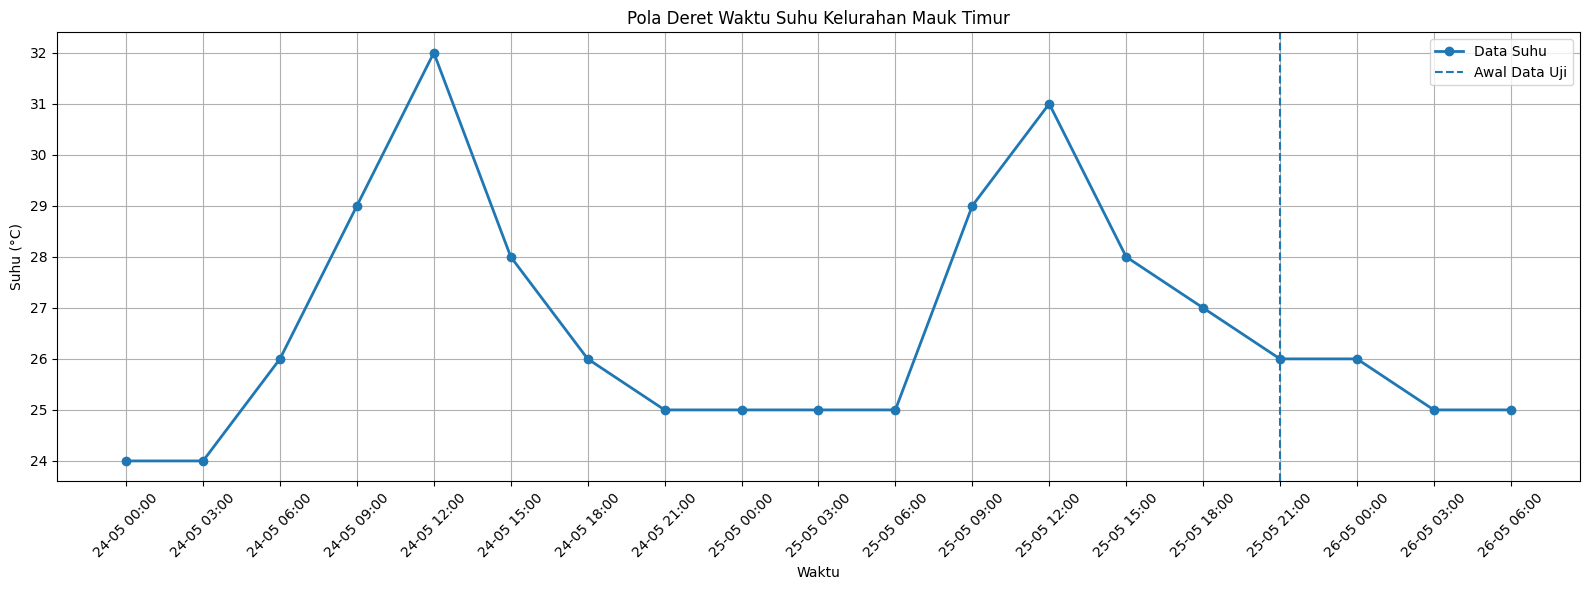

In [9]:
# =========================================
# BAGIAN 7
# VISUALISASI DATA TIME SERIES
# =========================================
plt.figure(
    figsize=(16, 6)
)

plt.plot(
    ts.index,
    ts.values,
    marker="o",
    linewidth=2,
    label="Data Suhu"
)

# Garis batas data latih dan data uji
plt.axvline(
    test.index[0],
    linestyle="--",
    label="Awal Data Uji"
)

plt.title(
    "Pola Deret Waktu Suhu Kelurahan Mauk Timur"
)

plt.xlabel(
    "Waktu"
)

plt.ylabel(
    "Suhu (°C)"
)

plt.xticks(
    ts.index,
    ts.index.strftime("%d-%m %H:%M"),
    rotation=45
)

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Bagian 8 — Uji Stasioneritas Data Latih (ADF)

Tahap ini menguji stasioneritas data latih menggunakan metode *Augmented Dickey-Fuller* (*ADF Test*). Pengujian dilakukan setelah pembagian data agar informasi dari data uji tidak memengaruhi proses penentuan model ARIMA. Hasil pengujian ditentukan berdasarkan nilai *p-value* pada tingkat signifikansi 0,05. Data latih dinyatakan stasioner apabila nilai *p-value* lebih kecil dari 0,05, sedangkan nilai yang lebih besar atau sama dengan 0,05 menunjukkan bahwa data memerlukan proses *differencing*.

In [10]:
# =========================================
# BAGIAN 8
# UJI STASIONERITAS DATA LATIH
# MENGGUNAKAN ADF
# =========================================

# Menyiapkan data latih
train_adf = (
    train
    .dropna()
    .astype(float)
)

# Menetapkan tingkat signifikansi
alpha = 0.05

# Melakukan uji ADF pada data latih
hasil_adf = adfuller(
    train_adf,
    autolag="AIC"
)

# Mengambil hasil uji
adf_statistic = hasil_adf[0]
p_value = hasil_adf[1]
critical_values = hasil_adf[4]

# Menampilkan hasil
print(
    "ADF Statistic:",
    adf_statistic
)

print(
    "P-Value:",
    p_value
)

print(
    "\nCritical Values:"
)

for key, value in critical_values.items():
    print(
        key,
        ":",
        value
    )

# Menentukan hasil uji
print(
    "\nKesimpulan:"
)

if p_value < alpha:
    print(
        "Data latih dinyatakan stasioner berdasarkan uji ADF"
    )

else:
    print(
        "Data latih belum stasioner dan memerlukan differencing"
    )

ADF Statistic: -4.374537816306223
P-Value: 0.0003291933164258322

Critical Values:
1% : -4.473135048010974
5% : -3.28988060356653
10% : -2.7723823456790124

Kesimpulan:
Data latih dinyatakan stasioner berdasarkan uji ADF


# Bagian 9 — Penentuan Orde *Differencing*

Tahap ini menentukan nilai parameter `d` berdasarkan hasil uji ADF pada data latih. Apabila nilai *p-value* lebih kecil dari 0,05, data latih dinyatakan stasioner sehingga proses *differencing* tidak dilakukan dan nilai `d` ditetapkan sebesar 0. Apabila nilai *p-value* lebih besar atau sama dengan 0,05, *first differencing* dilakukan dan nilai `d` sementara ditetapkan sebesar 1. Data hasil *first differencing* selanjutnya diuji kembali untuk memastikan bahwa kondisi stasioner telah terpenuhi.

In [11]:
# =========================================
# BAGIAN 9
# PENENTUAN ORDE DIFFERENCING
# =========================================

if p_value < alpha:

    # Data latih sudah stasioner
    d = 0

    # Data asli digunakan untuk tahap berikutnya
    data_stasioner = train_adf.copy()

    # Variabel hasil differencing tidak digunakan
    train_diff1 = None

    print(
        "Data latih sudah stasioner"
    )

    print(
        "First differencing tidak dilakukan"
    )

else:

    # Data latih belum stasioner
    d = 1

    # Melakukan first differencing
    train_diff1 = (
        train_adf
        .diff()
        .dropna()
    )

    # Menyimpan hasil differencing
    data_stasioner = train_diff1.copy()

    print(
        "Data latih belum stasioner"
    )

    print(
        "First differencing dilakukan"
    )

    print(
        "Jumlah data setelah differencing:",
        len(train_diff1)
    )

    print(
        "\n5 Data Pertama:"
    )

    display(
        train_diff1.head()
    )

    # =====================================
    # VISUALISASI HASIL DIFFERENCING
    # =====================================

    plt.figure(
        figsize=(16, 6)
    )

    plt.plot(
        train_diff1.index,
        train_diff1.values,
        marker="o",
        linewidth=2
    )

    plt.title(
        "First Differencing Data Latih Suhu "
        "Kelurahan Mauk Timur"
    )

    plt.xlabel(
        "Waktu"
    )

    plt.ylabel(
        "Selisih Suhu"
    )

    plt.xticks(
        ticks=train_diff1.index,
        labels=train_diff1.index.strftime(
            "%d-%m %H:%M"
        ),
        rotation=45
    )

    plt.grid(
        linestyle="--",
        alpha=0.7
    )

    plt.tight_layout()
    plt.show()

print(
    "Nilai parameter d:",
    d
)

Data latih sudah stasioner
First differencing tidak dilakukan
Nilai parameter d: 0


# Bagian 10 — Verifikasi Stasioneritas Setelah *Differencing*

Tahap ini menguji kembali stasioneritas data latih apabila *first differencing* dilakukan pada tahap sebelumnya. Pengujian menggunakan metode *Augmented Dickey-Fuller* (ADF) dengan tingkat signifikansi 0,05. Apabila nilai *p-value* lebih kecil dari 0,05, data hasil *first differencing* dinyatakan stasioner dan nilai parameter `d` ditetapkan sebesar 1. Apabila data masih belum stasioner, proses dilanjutkan dengan *second differencing* dan nilai parameter `d` ditetapkan sebesar 2 setelah kondisi stasioner terpenuhi.

In [12]:
# =========================================
# BAGIAN 10
# VERIFIKASI STASIONERITAS
# SETELAH DIFFERENCING
# =========================================

# Uji ulang hanya dilakukan apabila
# first differencing telah dilakukan
if d == 1:

    # Melakukan uji ADF pada data hasil
    # first differencing
    hasil_adf_diff1 = adfuller(
        train_diff1,
        autolag="AIC"
    )

    # Mengambil hasil pengujian
    adf_statistic_diff1 = hasil_adf_diff1[0]
    p_value_diff1 = hasil_adf_diff1[1]
    critical_values_diff1 = hasil_adf_diff1[4]

    # Menampilkan hasil
    print(
        "Hasil ADF setelah first differencing"
    )

    print(
        "ADF Statistic:",
        adf_statistic_diff1
    )

    print(
        "P-Value:",
        p_value_diff1
    )

    print(
        "\nCritical Values:"
    )

    for key, value in critical_values_diff1.items():
        print(
            key,
            ":",
            value
        )

    print(
        "\nKesimpulan:"
    )

    # Memeriksa hasil first differencing
    if p_value_diff1 < alpha:

        data_stasioner = train_diff1.copy()
        d = 1

        print(
            "Data hasil first differencing "
            "dinyatakan stasioner"
        )

    else:

        print(
            "Data hasil first differencing "
            "belum stasioner"
        )

        print(
            "Second differencing dilakukan"
        )

        # Melakukan second differencing
        train_diff2 = (
            train_diff1
            .diff()
            .dropna()
        )

        # Melakukan uji ADF kembali
        hasil_adf_diff2 = adfuller(
            train_diff2,
            autolag="AIC"
        )

        adf_statistic_diff2 = hasil_adf_diff2[0]
        p_value_diff2 = hasil_adf_diff2[1]
        critical_values_diff2 = hasil_adf_diff2[4]

        print(
            "\nHasil ADF setelah "
            "second differencing"
        )

        print(
            "ADF Statistic:",
            adf_statistic_diff2
        )

        print(
            "P-Value:",
            p_value_diff2
        )

        print(
            "\nCritical Values:"
        )

        for key, value in critical_values_diff2.items():
            print(
                key,
                ":",
                value
            )

        print(
            "\nKesimpulan:"
        )

        if p_value_diff2 < alpha:

            data_stasioner = train_diff2.copy()
            d = 2

            print(
                "Data hasil second differencing "
                "dinyatakan stasioner"
            )

        else:

            print(
                "Data masih belum stasioner "
                "setelah second differencing"
            )

else:

    # Data asli sudah stasioner
    # sehingga uji ulang tidak diperlukan
    data_stasioner = train_adf.copy()

    print(
        "Uji ADF setelah differencing "
        "tidak dilakukan"
    )

    print(
        "Data latih sudah stasioner "
        "tanpa differencing"
    )

# Menampilkan orde differencing akhir
print(
    "\nNilai parameter d akhir:",
    d
)

Uji ADF setelah differencing tidak dilakukan
Data latih sudah stasioner tanpa differencing

Nilai parameter d akhir: 0


# Bagian 11 — Identifikasi Parameter Menggunakan ACF dan PACF

Tahap ini mengidentifikasi kandidat parameter `p` dan `q` menggunakan grafik *Autocorrelation Function* (ACF) dan *Partial Autocorrelation Function* (PACF). Grafik ACF digunakan untuk membantu mengidentifikasi kandidat parameter *moving average* (`q`), sedangkan grafik PACF digunakan untuk membantu mengidentifikasi kandidat parameter *autoregressive* (`p`). Data yang digunakan merupakan data latih yang telah memenuhi kondisi stasioner berdasarkan hasil uji ADF dan proses *differencing* jika diperlukan. Karena jumlah data latih terbatas, grafik ACF dan PACF digunakan sebagai identifikasi awal, sedangkan pemilihan model ARIMA dilakukan melalui perbandingan beberapa kandidat berdasarkan nilai AIC.

Jumlah data stasioner: 15
Nilai parameter d: 0
Jumlah lag yang digunakan: 5


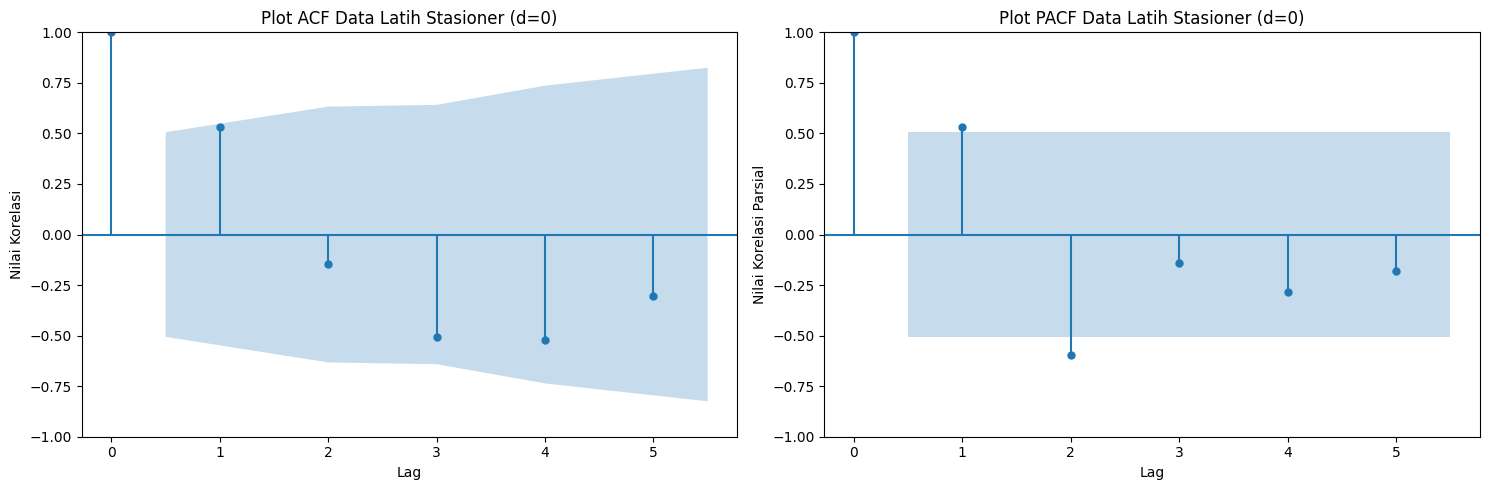

In [13]:
# =========================================
# BAGIAN 11
# IDENTIFIKASI PARAMETER
# ACF DAN PACF
# =========================================

# Memastikan data stasioner berbentuk numerik
data_acf_pacf = (
    data_stasioner
    .dropna()
    .astype(float)
)

# Menentukan jumlah lag berdasarkan
# panjang data yang tersedia
maks_lag = min(
    5,
    len(data_acf_pacf) // 2 - 1
)

print(
    "Jumlah data stasioner:",
    len(data_acf_pacf)
)

print(
    "Nilai parameter d:",
    d
)

print(
    "Jumlah lag yang digunakan:",
    maks_lag
)

# Pemeriksaan jumlah data
if maks_lag >= 1:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5)
    )

    # -------------------------------------
    # ACF
    # -------------------------------------
    plot_acf(
        data_acf_pacf,
        lags=maks_lag,
        ax=axes[0],
        zero=True
    )

    axes[0].set_xlabel(
        "Lag"
    )

    axes[0].set_ylabel(
        "Nilai Korelasi"
    )

    axes[0].set_title(
        f"Plot ACF Data Latih Stasioner (d={d})"
    )

    # -------------------------------------
    # PACF
    # -------------------------------------
    plot_pacf(
        data_acf_pacf,
        lags=maks_lag,
        ax=axes[1],
        method="ywm",
        zero=True
    )

    axes[1].set_xlabel(
        "Lag"
    )

    axes[1].set_ylabel(
        "Nilai Korelasi Parsial"
    )

    axes[1].set_title(
        f"Plot PACF Data Latih Stasioner (d={d})"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "Jumlah data terlalu sedikit untuk "
        "membentuk grafik ACF dan PACF"
    )

# Bagian 12 — Penentuan Kandidat Model ARIMA (`p`,`d`,`q`)

Tahap ini membentuk beberapa kandidat model ARIMA berdasarkan hasil uji stasioneritas serta identifikasi awal melalui grafik ACF dan PACF. Nilai parameter `d` menggunakan hasil yang telah ditentukan pada tahap sebelumnya, sedangkan nilai `p` dan `q` dibatasi pada beberapa kombinasi sederhana karena jumlah data latih relatif sedikit. Grafik ACF dan PACF tidak digunakan sebagai satu-satunya dasar penentuan parameter karena pola korelasi pada data berukuran kecil belum cukup tegas. Setiap kandidat selanjutnya dilatih menggunakan data latih dan dibandingkan berdasarkan nilai AIC pada tahap berikutnya.

Nilai MAE, RMSE, dan MAPE tidak digunakan untuk memilih kandidat ARIMA. Ketiga metrik tersebut dihitung setelah satu model ARIMA terpilih dan digunakan untuk mengevaluasi prediksi pada data uji. Pemisahan tersebut dilakukan agar informasi dari data uji tidak memengaruhi proses pemilihan model.

In [14]:
# =========================================
# BAGIAN 12
# PENENTUAN KANDIDAT MODEL
# ARIMA (p,d,q)
# =========================================

# Nilai d menggunakan hasil akhir
# dari proses uji stasioneritas
print(
    "Nilai parameter d yang digunakan:",
    d
)

# Memastikan nilai d masih dalam batas
# yang digunakan pada penelitian
if d not in [0, 1, 2]:
    raise ValueError(
        "Nilai parameter d harus 0, 1, atau 2"
    )

# Menentukan beberapa kandidat sederhana
# untuk parameter p dan q
kandidat_model = [
    (1, d, 0),
    (0, d, 1),
    (1, d, 1),
    (2, d, 1),
    (1, d, 2)
]

print(
    "\nDaftar kandidat model ARIMA:"
)

for order in kandidat_model:
    print(
        "ARIMA",
        order
    )

Nilai parameter d yang digunakan: 0

Daftar kandidat model ARIMA:
ARIMA (1, 0, 0)
ARIMA (0, 0, 1)
ARIMA (1, 0, 1)
ARIMA (2, 0, 1)
ARIMA (1, 0, 2)


# Bagian 13 — Pelatihan dan Seleksi Model ARIMA

Tahap ini melatih setiap kandidat model ARIMA menggunakan data latih yang telah disiapkan sebelumnya. Setiap kandidat menggunakan kombinasi parameter `p`, `d`, dan `q` yang telah dibentuk pada Bagian 12. Nilai AIC digunakan untuk membandingkan keseimbangan antara kesesuaian model dan tingkat kompleksitasnya. Kandidat dengan nilai AIC paling rendah dipilih sebagai model ARIMA untuk Kelurahan Mauk Timur.

Data uji belum digunakan pada proses seleksi kandidat. Data tersebut hanya digunakan setelah satu model ARIMA terpilih untuk menghitung MAE, RMSE, dan MAPE. Pemisahan ini menjaga agar hasil pada data uji tidak memengaruhi penentuan parameter model.

In [15]:
# =========================================
# BAGIAN 13
# PELATIHAN DAN SELEKSI MODEL ARIMA
# =========================================

# Menyiapkan penampung hasil kandidat
hasil_kandidat = []

# Melatih seluruh kandidat menggunakan data latih
for order in kandidat_model:

    try:
        print(
            "Melatih kandidat:",
            order
        )

        # Membentuk model
        model = ARIMA(
            train,
            order=order
        )

        # Melatih model
        model_fit = model.fit()

        # Memeriksa status konvergensi
        converged = model_fit.mle_retvals.get(
            "converged",
            True
        )

        if converged:

            hasil_kandidat.append({
                "Model": order,
                "AIC": model_fit.aic
            })

        else:

            print(
                "Kandidat tidak konvergen:",
                order
            )

    except Exception as e:

        print(
            "Kandidat gagal:",
            order
        )

        print(
            "Pesan kesalahan:",
            e
        )

# Memastikan terdapat kandidat yang berhasil
if len(hasil_kandidat) == 0:

    raise RuntimeError(
        "Seluruh kandidat ARIMA gagal dilatih "
        "atau tidak mencapai konvergensi"
    )

# Mengubah hasil menjadi dataframe
hasil_kandidat = pd.DataFrame(
    hasil_kandidat
)

# Mengurutkan kandidat berdasarkan AIC terkecil
hasil_kandidat = (
    hasil_kandidat
    .sort_values(
        by="AIC"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nHasil seleksi kandidat ARIMA:"
)

display(
    hasil_kandidat
)

# Mengambil model dengan AIC terkecil
order_terbaik = tuple(
    hasil_kandidat.loc[
        0,
        "Model"
    ]
)

aic_terbaik = hasil_kandidat.loc[
    0,
    "AIC"
]

print(
    "Model ARIMA terpilih:",
    order_terbaik
)

print(
    "Nilai AIC terendah:",
    round(
        aic_terbaik,
        4
    )
)

Melatih kandidat: (1, 0, 0)
Melatih kandidat: (0, 0, 1)
Melatih kandidat: (1, 0, 1)
Melatih kandidat: (2, 0, 1)
Melatih kandidat: (1, 0, 2)

Hasil seleksi kandidat ARIMA:


,Model,AIC
0,"(2, 0, 1)",60.441871
1,"(0, 0, 1)",66.130172
2,"(1, 0, 1)",67.641617
3,"(1, 0, 2)",68.097972
4,"(1, 0, 0)",69.658188


Model ARIMA terpilih: (2, 0, 1)
Nilai AIC terendah: 60.4419


# Bagian 14 — Prediksi, Evaluasi, dan Visualisasi Model ARIMA Terpilih

Tahap ini membentuk kembali model ARIMA menggunakan parameter yang telah dipilih berdasarkan nilai AIC terendah. Model dilatih menggunakan data latih, kemudian digunakan untuk memprediksi suhu pada periode data uji. Hasil prediksi dievaluasi menggunakan MAE, RMSE, dan MAPE untuk mengukur perbedaan antara nilai aktual dan nilai prediksi. Perbandingan data latih, Data Uji, dan hasil prediksi selanjutnya ditampilkan dalam bentuk grafik.

Model ARIMA yang digunakan: (2, 0, 1)
Nilai AIC: 60.4419
MAE: 1.2631
RMSE: 1.4053
MAPE: 4.9716 %

Hasil prediksi pada data uji:


,Waktu,suhu_data_uji,Prediksi_ARIMA
0,2026-05-25 21:00:00,26,25.179892
1,2026-05-26 00:00:00,26,24.720193
2,2026-05-26 03:00:00,25,25.691664
3,2026-05-26 06:00:00,25,27.260779


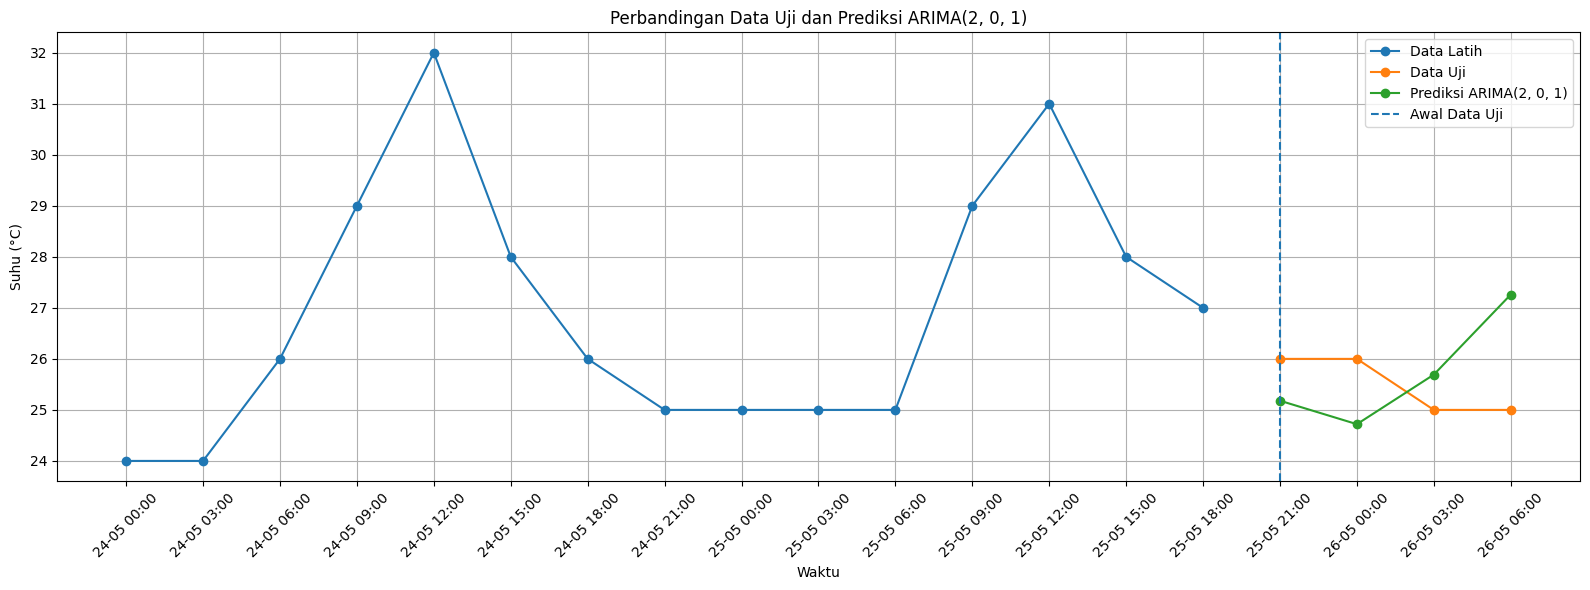

In [16]:
# =========================================
# BAGIAN 14
# PREDIKSI, EVALUASI, DAN VISUALISASI
# MODEL ARIMA TERPILIH
# =========================================

# =========================================
# MEMBENTUK MODEL ARIMA TERPILIH
# =========================================

model_arima_terbaik = ARIMA(
    train,
    order=order_terbaik
)

# Melatih model menggunakan data latih
fit_arima_terbaik = (
    model_arima_terbaik.fit()
)

# =========================================
# MELAKUKAN PREDIKSI DATA UJI
# =========================================

prediksi_arima = (
    fit_arima_terbaik.forecast(
        steps=len(test)
    )
)

# Menyamakan indeks prediksi
# dengan indeks data uji
prediksi_arima = pd.Series(
    prediksi_arima.values,
    index=test.index,
    name="Prediksi_ARIMA"
)

# =========================================
# EVALUASI MODEL ARIMA
# =========================================

mae_arima = mean_absolute_error(
    test,
    prediksi_arima
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test,
        prediksi_arima
    )
)

# MAPE dari sklearn berbentuk desimal
mape_arima = mean_absolute_percentage_error(
    test,
    prediksi_arima
)

# Mengubah MAPE menjadi persen
mape_arima_persen = (
    mape_arima * 100
)

# =========================================
# MENAMPILKAN HASIL
# =========================================

print(
    "Model ARIMA yang digunakan:",
    order_terbaik
)

print(
    "Nilai AIC:",
    round(
        fit_arima_terbaik.aic,
        4
    )
)

print(
    "MAE:",
    round(
        mae_arima,
        4
    )
)

print(
    "RMSE:",
    round(
        rmse_arima,
        4
    )
)

print(
    "MAPE:",
    round(
        mape_arima_persen,
        4
    ),
    "%"
)

# Menampilkan nilai aktual dan prediksi
hasil_prediksi_arima = pd.DataFrame({
    "Waktu": test.index,
    "suhu_data_uji": test.values,
    "Prediksi_ARIMA": prediksi_arima.values
})

print(
    "\nHasil prediksi pada data uji:"
)

display(
    hasil_prediksi_arima
)

# =========================================
# VISUALISASI HASIL PREDIKSI
# =========================================

plt.figure(
    figsize=(16, 6)
)

# Data latih
plt.plot(
    train.index,
    train.values,
    label="Data Latih",
    marker="o"
)

# Data Uji pada periode pengujian
plt.plot(
    test.index,
    test.values,
    label="Data Uji",
    marker="o"
)

# Hasil prediksi ARIMA
plt.plot(
    prediksi_arima.index,
    prediksi_arima.values,
    label=f"Prediksi ARIMA{order_terbaik}",
    marker="o"
)

# Menandai awal periode pengujian
plt.axvline(
    x=test.index[0],
    linestyle="--",
    label="Awal Data Uji"
)

plt.title(
    "Perbandingan Data Uji dan Prediksi "
    f"ARIMA{order_terbaik}"
)

plt.xlabel(
    "Waktu"
)

plt.ylabel(
    "Suhu (°C)"
)

plt.xticks(
    ticks=ts.index,
    labels=ts.index.strftime(
        "%d-%m %H:%M"
    ),
    rotation=45
)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Interpretasi Hasil Pemodelan ARIMA

Berdasarkan proses seleksi kandidat, ARIMA(2,0,1) menghasilkan nilai AIC terendah sebesar 60,4419. Model tersebut kemudian digunakan untuk memprediksi empat observasi pada data uji. Hasil evaluasi menunjukkan nilai MAE sebesar 1,2631, RMSE sebesar 1,4053, dan MAPE sebesar 4,9716%. Hasil ini menggambarkan kinerja model ARIMA pada Kelurahan Mauk Timur dan belum menunjukkan model terbaik secara keseluruhan karena masih harus dibandingkan dengan Prophet.

,Waktu,Suhu_Data_Uji,Prediksi_ARIMA,Kesalahan_Absolut
0,2026-05-25 21:00:00,26,25.1799,0.8201
1,2026-05-26 00:00:00,26,24.7202,1.2798
2,2026-05-26 03:00:00,25,25.6917,0.6917
3,2026-05-26 06:00:00,25,27.2608,2.2608


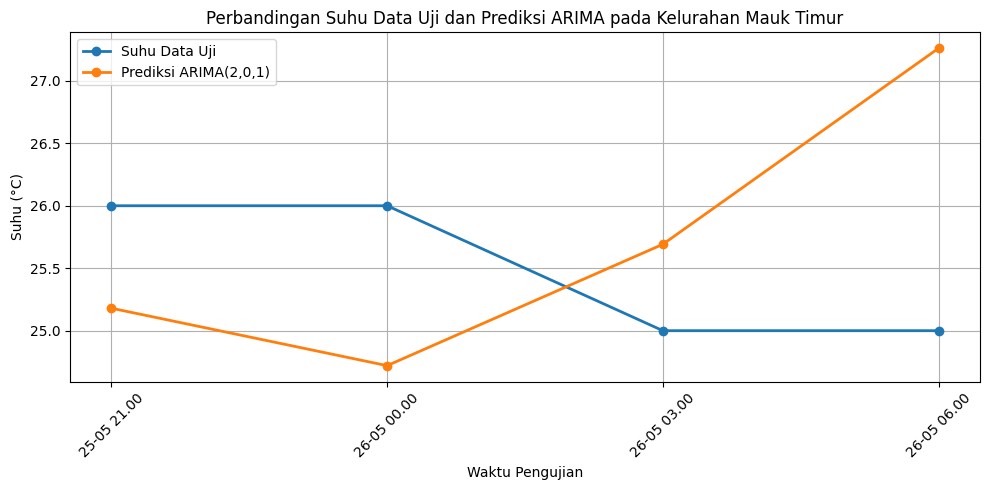

In [17]:
# Membentuk tabel hasil prediksi
tabel_prediksi_arima = pd.DataFrame({
    "Waktu": test.index,
    "Suhu_Data_Uji": test.values,
    "Prediksi_ARIMA": prediksi_arima.values
})

# Menghitung kesalahan absolut
tabel_prediksi_arima["Kesalahan_Absolut"] = np.abs(
    tabel_prediksi_arima["Suhu_Data_Uji"]
    - tabel_prediksi_arima["Prediksi_ARIMA"]
)

display(tabel_prediksi_arima.round(4))

# Membuat grafik khusus periode pengujian
plt.figure(figsize=(10, 5))

plt.plot(
    test.index,
    test.values,
    marker="o",
    linewidth=2,
    label="Suhu Data Uji"
)

plt.plot(
    prediksi_arima.index,
    prediksi_arima.values,
    marker="o",
    linewidth=2,
    label="Prediksi ARIMA(2,0,1)"
)

plt.title(
    "Perbandingan Suhu Data Uji dan Prediksi ARIMA "
    "pada Kelurahan Mauk Timur"
)
plt.xlabel("Waktu Pengujian")
plt.ylabel("Suhu (°C)")
plt.xticks(
    test.index,
    test.index.strftime("%d-%m %H.%M"),
    rotation=45
)
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig(
    "perbandingan_data_uji_prediksi_arima_mauk_timur.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bagian 15 — Persiapan Data untuk Model Prophet

Tahap ini menyesuaikan struktur data latih dan data uji dengan format yang dibutuhkan oleh Prophet. Atribut waktu diubah menjadi `ds`, sedangkan nilai suhu sebagai variabel target diubah menjadi `y`. Data latih dan data uji menggunakan pembagian yang sama dengan model ARIMA agar kedua metode diterapkan pada periode yang setara. Data yang telah disesuaikan selanjutnya digunakan untuk pelatihan dan pengujian model Prophet pada tahap berikutnya.

In [18]:
# =========================================
# BAGIAN 15
# PERSIAPAN DATA UNTUK MODEL PROPHET
# =========================================

# =========================================
# MENYIAPKAN DATA LATIH PROPHET
# =========================================

# Mengubah indeks datetime menjadi kolom
train_prophet = (
    train
    .rename("y")
    .reset_index()
)

# Mengubah nama atribut waktu menjadi ds
train_prophet.columns = [
    "ds",
    "y"
]

# Memastikan tipe data sesuai
train_prophet["ds"] = pd.to_datetime(
    train_prophet["ds"]
)

train_prophet["y"] = train_prophet[
    "y"
].astype(float)

# =========================================
# MENYIAPKAN DATA UJI PROPHET
# =========================================

# Mengubah indeks datetime menjadi kolom
test_prophet = (
    test
    .rename("y")
    .reset_index()
)

# Mengubah nama atribut waktu menjadi ds
test_prophet.columns = [
    "ds",
    "y"
]

# Memastikan tipe data sesuai
test_prophet["ds"] = pd.to_datetime(
    test_prophet["ds"]
)

test_prophet["y"] = test_prophet[
    "y"
].astype(float)

# =========================================
# MEMBENTUK DATA PROPHET LENGKAP
# =========================================

# Data lengkap hanya digunakan untuk
# pemeriksaan dan kebutuhan visualisasi
df_prophet = pd.concat(
    [
        train_prophet,
        test_prophet
    ],
    ignore_index=True
)

# =========================================
# VALIDASI PEMBAGIAN DATA
# =========================================

# Memastikan jumlah data sama dengan ARIMA
assert len(train_prophet) == len(train)
assert len(test_prophet) == len(test)

# Memastikan waktu pengujian sama
assert (
    test_prophet["ds"].tolist()
    ==
    list(test.index)
)

# =========================================
# MENAMPILKAN INFORMASI
# =========================================

print(
    "Jumlah data Prophet:",
    len(df_prophet)
)

print(
    "Jumlah data latih Prophet:",
    len(train_prophet)
)

print(
    "Jumlah data uji Prophet:",
    len(test_prophet)
)

print(
    "\nPeriode data latih:"
)

print(
    train_prophet["ds"].min(),
    "sampai",
    train_prophet["ds"].max()
)

print(
    "\nPeriode data uji:"
)

print(
    test_prophet["ds"].min(),
    "sampai",
    test_prophet["ds"].max()
)

print(
    "\n5 Data Latih Pertama:"
)

display(
    train_prophet.head()
)

print(
    "\nData Uji Prophet:"
)

display(
    test_prophet
)

Jumlah data Prophet: 19
Jumlah data latih Prophet: 15
Jumlah data uji Prophet: 4

Periode data latih:
2026-05-24 00:00:00 sampai 2026-05-25 18:00:00

Periode data uji:
2026-05-25 21:00:00 sampai 2026-05-26 06:00:00

5 Data Latih Pertama:


,ds,y
0,2026-05-24 00:00:00,24.0
1,2026-05-24 03:00:00,24.0
2,2026-05-24 06:00:00,26.0
3,2026-05-24 09:00:00,29.0
4,2026-05-24 12:00:00,32.0



Data Uji Prophet:


,ds,y
0,2026-05-25 21:00:00,26.0
1,2026-05-26 00:00:00,26.0
2,2026-05-26 03:00:00,25.0
3,2026-05-26 06:00:00,25.0


# Bagian 16 — Pelatihan, Prediksi, dan Evaluasi Prophet

Tahap ini melatih model Prophet menggunakan data latih yang telah disusun dalam atribut `ds` dan `y`. Model kemudian digunakan untuk memprediksi suhu pada waktu yang sama dengan periode data uji. Hasil prediksi dibandingkan dengan nilai aktual menggunakan MAE, RMSE, dan MAPE. Pembagian data tidak dilakukan kembali karena data latih dan data uji telah ditetapkan pada tahap sebelumnya.

Jumlah data latih Prophet: 15
Jumlah data uji Prophet: 4

MAE: 2.8745
RMSE: 2.9481
MAPE: 11.3268 %

Hasil prediksi Prophet pada data uji:


,Waktu,suhu_data_uji,Prediksi_Prophet
0,2026-05-25 21:00:00,26.0,28.148678
1,2026-05-26 00:00:00,26.0,28.299212
2,2026-05-26 03:00:00,25.0,28.449746
3,2026-05-26 06:00:00,25.0,28.600280


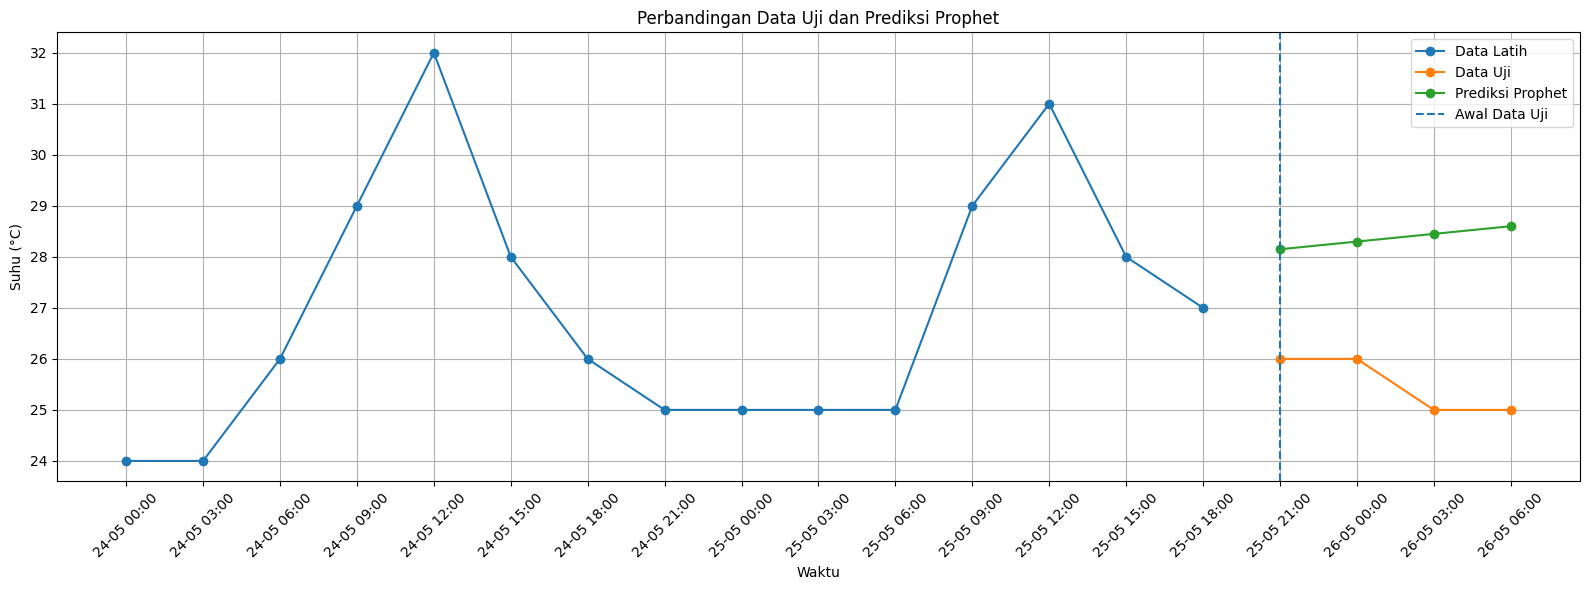

In [19]:
# =========================================
# BAGIAN 16
# PELATIHAN, PREDIKSI, DAN EVALUASI
# MODEL PROPHET
# =========================================

# =========================================
# MENGURANGI LOG INFORMASI PROPHET
# =========================================

import logging

logging.getLogger(
    "prophet"
).setLevel(
    logging.ERROR
)

logging.getLogger(
    "cmdstanpy"
).setLevel(
    logging.ERROR
)

# =========================================
# VALIDASI DATA PROPHET
# =========================================

# Memastikan kolom yang diperlukan tersedia
kolom_wajib = {
    "ds",
    "y"
}

if not kolom_wajib.issubset(
    train_prophet.columns
):
    raise ValueError(
        "Data latih Prophet harus memiliki "
        "atribut ds dan y"
    )

if not kolom_wajib.issubset(
    test_prophet.columns
):
    raise ValueError(
        "Data uji Prophet harus memiliki "
        "atribut ds dan y"
    )

# Memastikan jumlah data sesuai
if len(train_prophet) != len(train):
    raise ValueError(
        "Jumlah data latih Prophet "
        "tidak sama dengan ARIMA"
    )

if len(test_prophet) != len(test):
    raise ValueError(
        "Jumlah data uji Prophet "
        "tidak sama dengan ARIMA"
    )

# =========================================
# MEMBANGUN DAN MELATIH MODEL PROPHET
# =========================================

model_prophet = Prophet()

model_prophet.fit(
    train_prophet[
        [
            "ds",
            "y"
        ]
    ]
)

# =========================================
# MELAKUKAN PREDIKSI PADA DATA UJI
# =========================================

# Menggunakan waktu yang sama dengan data uji
waktu_uji_prophet = test_prophet[
    [
        "ds"
    ]
].copy()

forecast_prophet = model_prophet.predict(
    waktu_uji_prophet
)

# Membentuk nilai aktual dan prediksi
aktual_prophet = pd.Series(
    test_prophet["y"].to_numpy(),
    index=pd.DatetimeIndex(
        test_prophet["ds"]
    ),
    name="suhu_data_uji"
)

prediksi_prophet = pd.Series(
    forecast_prophet["yhat"].to_numpy(),
    index=pd.DatetimeIndex(
        forecast_prophet["ds"]
    ),
    name="Prediksi_Prophet"
)

# Memastikan waktu aktual dan prediksi sama
if not aktual_prophet.index.equals(
    prediksi_prophet.index
):
    raise ValueError(
        "Waktu prediksi Prophet tidak sama "
        "dengan waktu data uji"
    )

# =========================================
# EVALUASI MODEL PROPHET
# =========================================

mae_prophet = mean_absolute_error(
    aktual_prophet,
    prediksi_prophet
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        aktual_prophet,
        prediksi_prophet
    )
)

# Nilai awal MAPE berbentuk desimal
mape_prophet = (
    mean_absolute_percentage_error(
        aktual_prophet,
        prediksi_prophet
    )
)

# Mengubah MAPE menjadi persen
mape_prophet_persen = (
    mape_prophet * 100
)

# =========================================
# MENAMPILKAN HASIL EVALUASI
# =========================================

print(
    "Jumlah data latih Prophet:",
    len(train_prophet)
)

print(
    "Jumlah data uji Prophet:",
    len(test_prophet)
)

print(
    "\nMAE:",
    round(
        mae_prophet,
        4
    )
)

print(
    "RMSE:",
    round(
        rmse_prophet,
        4
    )
)

print(
    "MAPE:",
    round(
        mape_prophet_persen,
        4
    ),
    "%"
)

# =========================================
# MEMBENTUK TABEL HASIL PREDIKSI
# =========================================

hasil_prediksi_prophet = pd.DataFrame({
    "Waktu": aktual_prophet.index,
    "suhu_data_uji": aktual_prophet.values,
    "Prediksi_Prophet": prediksi_prophet.values
})

print(
    "\nHasil prediksi Prophet "
    "pada data uji:"
)

display(
    hasil_prediksi_prophet
)

# =========================================
# VISUALISASI HASIL PREDIKSI PROPHET
# =========================================

plt.figure(
    figsize=(16, 6)
)

# Data latih
plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Data Latih",
    marker="o"
)

# Data Uji pada periode pengujian
plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Data Uji",
    marker="o"
)

# Hasil prediksi Prophet
plt.plot(
    forecast_prophet["ds"],
    forecast_prophet["yhat"],
    label="Prediksi Prophet",
    marker="o"
)

# Menandai awal data uji
plt.axvline(
    x=test_prophet["ds"].iloc[0],
    linestyle="--",
    label="Awal Data Uji"
)

plt.title(
    "Perbandingan Data Uji "
    "dan Prediksi Prophet"
)

plt.xlabel(
    "Waktu"
)

plt.ylabel(
    "Suhu (°C)"
)

plt.xticks(
    ticks=df_prophet["ds"],
    labels=df_prophet["ds"].dt.strftime(
        "%d-%m %H:%M"
    ),
    rotation=45
)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

,Waktu,suhu_data_uji,Prediksi_Prophet,Kesalahan_Absolut
0,2026-05-25 21:00:00,26.0,28.1487,2.1487
1,2026-05-26 00:00:00,26.0,28.2992,2.2992
2,2026-05-26 03:00:00,25.0,28.4497,3.4497
3,2026-05-26 06:00:00,25.0,28.6003,3.6003


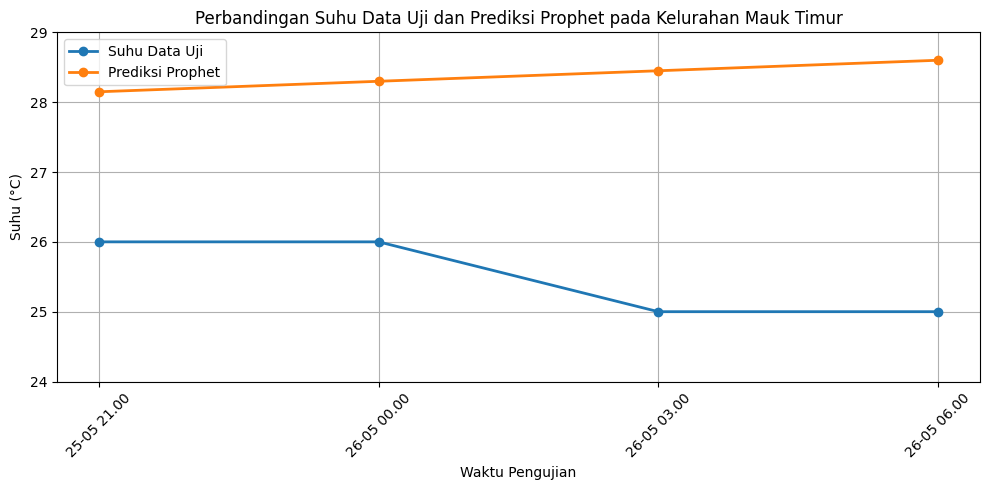

In [33]:
# =========================================
# MENAMBAHKAN KESALAHAN ABSOLUT
# =========================================

hasil_prediksi_prophet[
    "Kesalahan_Absolut"
] = np.abs(
    hasil_prediksi_prophet["suhu_data_uji"]
    - hasil_prediksi_prophet["Prediksi_Prophet"]
)

# Menampilkan hasil dengan empat angka desimal
display(
    hasil_prediksi_prophet.round(4)
)

# =========================================
# VISUALISASI KHUSUS PERIODE DATA UJI
# =========================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    aktual_prophet.index,
    aktual_prophet.values,
    marker="o",
    linewidth=2,
    label="Suhu Data Uji"
)

plt.plot(
    prediksi_prophet.index,
    prediksi_prophet.values,
    marker="o",
    linewidth=2,
    label="Prediksi Prophet"
)

plt.title(
    "Perbandingan Suhu Data Uji dan Prediksi Prophet "
    "pada Kelurahan Mauk Timur"
)

plt.xlabel(
    "Waktu Pengujian"
)

plt.ylabel(
    "Suhu (°C)"
)

plt.xticks(
    aktual_prophet.index,
    aktual_prophet.index.strftime("%d-%m %H.%M"),
    rotation=45
)

plt.legend()
plt.grid()
plt.ylim(24, 29)
plt.tight_layout()

plt.savefig(
    "perbandingan_data_uji_prediksi_prophet_mauk_timur.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bagian 17 — Perbandingan Kinerja ARIMA dan Prophet

Tahap ini membandingkan kinerja model ARIMA dan Prophet pada data uji Kelurahan Mauk Timur. Perbandingan menggunakan MAE, RMSE, dan MAPE yang telah dihitung pada tahap sebelumnya. Nilai kesalahan yang lebih rendah menunjukkan hasil prediksi yang lebih dekat dengan nilai aktual. Model dinyatakan unggul apabila menghasilkan nilai kesalahan lebih rendah pada seluruh metrik yang digunakan.

In [21]:
# =========================================
# BAGIAN 17
# PERBANDINGAN KINERJA
# ARIMA DAN PROPHET
# =========================================

# =========================================
# VALIDASI NILAI EVALUASI
# =========================================

nilai_evaluasi = [
    mae_arima,
    rmse_arima,
    mape_arima_persen,
    mae_prophet,
    rmse_prophet,
    mape_prophet_persen
]

if not np.all(
    np.isfinite(nilai_evaluasi)
):
    raise ValueError(
        "Terdapat nilai evaluasi yang "
        "tidak valid"
    )

# =========================================
# MEMBENTUK TABEL PERBANDINGAN
# =========================================

nama_arima = (
    f"ARIMA{order_terbaik}"
)

perbandingan = pd.DataFrame({
    "Model": [
        nama_arima,
        "Prophet"
    ],
    "MAE": [
        mae_arima,
        mae_prophet
    ],
    "RMSE": [
        rmse_arima,
        rmse_prophet
    ],
    "MAPE (%)": [
        mape_arima_persen,
        mape_prophet_persen
    ]
})

# Membulatkan tampilan tanpa mengubah
# nilai asli untuk proses perbandingan
perbandingan_tampilan = (
    perbandingan.copy()
)

kolom_metrik = [
    "MAE",
    "RMSE",
    "MAPE (%)"
]

perbandingan_tampilan[
    kolom_metrik
] = perbandingan_tampilan[
    kolom_metrik
].round(4)

print(
    "Perbandingan kinerja ARIMA "
    "dan Prophet:"
)

display(
    perbandingan_tampilan
)

# =========================================
# MENENTUKAN MODEL DENGAN NILAI
# TERENDAH PADA SETIAP METRIK
# =========================================

pemenang_mae = perbandingan.loc[
    perbandingan["MAE"].idxmin(),
    "Model"
]

pemenang_rmse = perbandingan.loc[
    perbandingan["RMSE"].idxmin(),
    "Model"
]

pemenang_mape = perbandingan.loc[
    perbandingan["MAPE (%)"].idxmin(),
    "Model"
]

print(
    "\nModel dengan MAE terendah:",
    pemenang_mae
)

print(
    "Model dengan RMSE terendah:",
    pemenang_rmse
)

print(
    "Model dengan MAPE terendah:",
    pemenang_mape
)

# =========================================
# MENENTUKAN HASIL PERBANDINGAN
# =========================================

pemenang_metrik = {
    pemenang_mae,
    pemenang_rmse,
    pemenang_mape
}

if len(pemenang_metrik) == 1:

    model_terbaik = pemenang_mae

    print(
        "\nModel dengan tingkat kesalahan "
        "lebih rendah pada seluruh metrik:",
        model_terbaik
    )

else:

    model_terbaik = None

    print(
        "\nTidak terdapat satu model yang "
        "unggul pada seluruh metrik"
    )

    print(
        "Penentuan akhir harus mengikuti "
        "kriteria evaluasi yang ditetapkan"
    )

Perbandingan kinerja ARIMA dan Prophet:


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(2, 0, 1)",1.2631,1.4053,4.9716
1,Prophet,2.8745,2.9481,11.3268



Model dengan MAE terendah: ARIMA(2, 0, 1)
Model dengan RMSE terendah: ARIMA(2, 0, 1)
Model dengan MAPE terendah: ARIMA(2, 0, 1)

Model dengan tingkat kesalahan lebih rendah pada seluruh metrik: ARIMA(2, 0, 1)


# Bagian 18 — Persiapan Pemodelan Seluruh Wilayah

Tahap ini menyiapkan seluruh wilayah sebelum proses pemodelan otomatis dilakukan. Daftar wilayah diperoleh dari atribut `wilayah` pada kumpulan data dan diperiksa untuk memastikan bahwa jumlahnya sesuai dengan cakupan penelitian. Jumlah observasi, periode data, dan kode ADM4 pada setiap wilayah juga diperiksa agar proses pemodelan menggunakan struktur data yang konsisten. Setiap wilayah selanjutnya diproses secara terpisah menggunakan tahapan ARIMA dan Prophet yang sama.

In [22]:
# =========================================
# BAGIAN 18
# PERSIAPAN PEMODELAN
# SELURUH WILAYAH
# =========================================

# =========================================
# MEMERIKSA ATRIBUT YANG DIBUTUHKAN
# =========================================

kolom_wajib = {
    "datetime",
    "wilayah",
    "adm4",
    "suhu"
}

kolom_tersedia = set(
    df_cuaca.columns
)

kolom_tidak_tersedia = (
    kolom_wajib - kolom_tersedia
)

if kolom_tidak_tersedia:

    raise ValueError(
        "Atribut berikut tidak tersedia: "
        f"{sorted(kolom_tidak_tersedia)}"
    )

# =========================================
# MENYIAPKAN DATA
# =========================================

data_seluruh_wilayah = (
    df_cuaca.copy()
)

data_seluruh_wilayah[
    "datetime"
] = pd.to_datetime(
    data_seluruh_wilayah["datetime"]
)

# Mengurutkan data berdasarkan
# wilayah dan waktu
data_seluruh_wilayah = (
    data_seluruh_wilayah
    .sort_values(
        by=[
            "wilayah",
            "datetime"
        ]
    )
    .reset_index(
        drop=True
    )
)

# =========================================
# MENGAMBIL DAFTAR WILAYAH
# =========================================

daftar_wilayah = sorted(
    data_seluruh_wilayah[
        "wilayah"
    ]
    .dropna()
    .unique()
    .tolist()
)

jumlah_wilayah = len(
    daftar_wilayah
)

print(
    "Jumlah wilayah:",
    jumlah_wilayah
)

# Memastikan jumlah wilayah sesuai
# dengan cakupan penelitian
if jumlah_wilayah != 28:

    raise ValueError(
        "Jumlah wilayah tidak sesuai. "
        f"Ditemukan {jumlah_wilayah} wilayah, "
        "sedangkan penelitian menggunakan "
        "28 wilayah."
    )

# =========================================
# MENAMPILKAN DAFTAR WILAYAH
# =========================================

tabel_daftar_wilayah = pd.DataFrame({
    "No": range(
        1,
        jumlah_wilayah + 1
    ),
    "Wilayah": daftar_wilayah
})

print(
    "\nDaftar wilayah penelitian:"
)

display(
    tabel_daftar_wilayah
)

# =========================================
# MEMERIKSA STRUKTUR SETIAP WILAYAH
# =========================================

ringkasan_wilayah = (
    data_seluruh_wilayah
    .groupby(
        "wilayah",
        as_index=False
    )
    .agg(
        Kode_ADM4=(
            "adm4",
            "first"
        ),
        Jumlah_Kode_ADM4=(
            "adm4",
            "nunique"
        ),
        Jumlah_Data=(
            "suhu",
            "size"
        ),
        Waktu_Awal=(
            "datetime",
            "min"
        ),
        Waktu_Akhir=(
            "datetime",
            "max"
        )
    )
    .sort_values(
        by="wilayah"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nRingkasan data setiap wilayah:"
)

display(
    ringkasan_wilayah
)

# =========================================
# VALIDASI KONSISTENSI DATA
# =========================================

jumlah_data_unik = (
    ringkasan_wilayah[
        "Jumlah_Data"
    ]
    .unique()
)

if len(jumlah_data_unik) != 1:

    raise ValueError(
        "Jumlah observasi antarwilayah "
        "tidak sama."
    )

jumlah_data_per_wilayah = int(
    jumlah_data_unik[0]
)

if jumlah_data_per_wilayah != 19:

    raise ValueError(
        "Jumlah observasi setiap wilayah "
        f"adalah {jumlah_data_per_wilayah}, "
        "bukan 19."
    )

if not (
    ringkasan_wilayah[
        "Jumlah_Kode_ADM4"
    ] == 1
).all():

    raise ValueError(
        "Terdapat wilayah yang memiliki "
        "lebih dari satu kode ADM4."
    )

print(
    "\nValidasi data berhasil"
)

print(
    "Jumlah wilayah:",
    jumlah_wilayah
)

print(
    "Jumlah data setiap wilayah:",
    jumlah_data_per_wilayah
)

print(
    "Seluruh wilayah memiliki satu "
    "kode ADM4"
)

Jumlah wilayah: 28

Daftar wilayah penelitian:


,No,Wilayah
0,1,Babakan
1,2,Balaraja
2,3,Bencongan
3,4,Bencongan Indah
4,5,Binong
5,6,Bojong Nangka
6,7,Bunder
7,8,Cisauk
8,9,Curug Kulon
9,10,Dadap



Ringkasan data setiap wilayah:


,wilayah,Kode_ADM4,Jumlah_Kode_ADM4,Jumlah_Data,Waktu_Awal,Waktu_Akhir
0,Babakan,36.03.20.1011,1,19,2026-05-24,2026-05-26 06:00:00
1,Balaraja,36.03.01.1001,1,19,2026-05-24,2026-05-26 06:00:00
2,Bencongan,36.03.28.1002,1,19,2026-05-24,2026-05-26 06:00:00
3,Bencongan Indah,36.03.28.1003,1,19,2026-05-24,2026-05-26 06:00:00
4,Binong,36.03.17.1006,1,19,2026-05-24,2026-05-26 06:00:00
5,Bojong Nangka,36.03.28.1005,1,19,2026-05-24,2026-05-26 06:00:00
6,Bunder,36.03.18.1003,1,19,2026-05-24,2026-05-26 06:00:00
7,Cisauk,36.03.23.1001,1,19,2026-05-24,2026-05-26 06:00:00
8,Curug Kulon,36.03.17.1001,1,19,2026-05-24,2026-05-26 06:00:00
9,Dadap,36.03.14.1010,1,19,2026-05-24,2026-05-26 06:00:00



Validasi data berhasil
Jumlah wilayah: 28
Jumlah data setiap wilayah: 19
Seluruh wilayah memiliki satu kode ADM4


# Bagian 19 — Pemodelan ARIMA dan Prophet pada Seluruh Wilayah

Tahap ini menerapkan pemodelan ARIMA dan Prophet secara berulang pada 28 kelurahan. Data pada setiap wilayah diurutkan berdasarkan waktu, kemudian dibagi secara kronologis menjadi 80% data latih dan 20% data uji. Nilai parameter `d` ditentukan melalui uji ADF pada data latih, sedangkan model ARIMA dipilih dari beberapa kandidat berdasarkan nilai AIC terendah. Model Prophet dilatih menggunakan data latih dan memprediksi titik waktu yang sama dengan data uji.

Hasil prediksi kedua model dievaluasi menggunakan MAE, RMSE, dan MAPE. Model dengan nilai terendah pada setiap metrik dicatat untuk setiap wilayah. Satu model hanya dinyatakan unggul apabila menghasilkan nilai lebih rendah pada seluruh metrik. Hasil evaluasi dan prediksi disimpan dalam tabel agar dapat digunakan pada tahap perbandingan dan penyajian hasil.

In [23]:
# =========================================
# BAGIAN 19
# PEMODELAN ARIMA DAN PROPHET
# PADA SELURUH WILAYAH
# =========================================

import warnings
import logging

# Mengurangi log Prophet
logging.getLogger(
    "prophet"
).setLevel(
    logging.ERROR
)

logging.getLogger(
    "cmdstanpy"
).setLevel(
    logging.ERROR
)

# =========================================
# FUNGSI MENENTUKAN ORDE DIFFERENCING
# =========================================

def tentukan_nilai_d(
    data_latih,
    alpha=0.05,
    d_maksimum=2
):
    """
    Menentukan nilai d berdasarkan uji ADF
    pada data latih.
    """

    data_uji_adf = (
        data_latih
        .dropna()
        .astype(float)
        .copy()
    )

    # Deret konstan diperlakukan sebagai
    # deret yang tidak memerlukan differencing
    if data_uji_adf.nunique() <= 1:
        return 0, "Deret konstan"

    for nilai_d in range(
        d_maksimum + 1
    ):

        try:
            hasil_adf_wilayah = adfuller(
                data_uji_adf,
                autolag="AIC"
            )

            p_value_wilayah = (
                hasil_adf_wilayah[1]
            )

            if p_value_wilayah < alpha:
                return (
                    nilai_d,
                    f"p-value={p_value_wilayah:.6f}"
                )

        except Exception as e:
            return (
                nilai_d,
                f"Uji ADF gagal: {e}"
            )

        # Differencing untuk pengujian berikutnya
        data_uji_adf = (
            data_uji_adf
            .diff()
            .dropna()
        )

    return (
        d_maksimum,
        "Belum stasioner sampai d maksimum"
    )


# =========================================
# FUNGSI MENYELEKSI MODEL ARIMA
# =========================================

def seleksi_model_arima(
    data_latih,
    nilai_d
):
    """
    Melatih kandidat ARIMA menggunakan
    data latih dan memilih model dengan
    AIC terendah.
    """

    kandidat_arima = [
        (1, nilai_d, 0),
        (0, nilai_d, 1),
        (1, nilai_d, 1),
        (2, nilai_d, 1),
        (1, nilai_d, 2)
    ]

    hasil_seleksi = []

    for order in kandidat_arima:

        try:
            with warnings.catch_warnings():
                warnings.simplefilter(
                    "ignore"
                )

                model = ARIMA(
                    data_latih,
                    order=order
                )

                model_fit = model.fit()

            # Memeriksa konvergensi
            informasi_konvergensi = getattr(
                model_fit,
                "mle_retvals",
                {}
            )

            converged = (
                informasi_konvergensi.get(
                    "converged",
                    True
                )
            )

            if converged and np.isfinite(
                model_fit.aic
            ):
                hasil_seleksi.append({
                    "Model": order,
                    "AIC": model_fit.aic,
                    "Model_Fit": model_fit
                })

        except Exception:
            # Kandidat yang gagal tidak disimpan
            continue

    if len(hasil_seleksi) == 0:
        raise RuntimeError(
            "Tidak terdapat kandidat ARIMA "
            "yang berhasil dilatih"
        )

    hasil_seleksi = sorted(
        hasil_seleksi,
        key=lambda hasil: hasil["AIC"]
    )

    return hasil_seleksi[0], hasil_seleksi


# =========================================
# MENYIAPKAN PENAMPUNG HASIL
# =========================================

hasil_evaluasi_semua = []
hasil_prediksi_semua = []
hasil_kandidat_semua = []
wilayah_gagal = []

# =========================================
# PERULANGAN SELURUH WILAYAH
# =========================================

for nomor, wilayah in enumerate(
    daftar_wilayah,
    start=1
):

    print(
        f"[{nomor}/{len(daftar_wilayah)}] "
        f"Memproses {wilayah}"
    )

    try:
        # ---------------------------------
        # MENYIAPKAN DATA WILAYAH
        # ---------------------------------

        data_wilayah = (
            data_seluruh_wilayah[
                data_seluruh_wilayah[
                    "wilayah"
                ] == wilayah
            ]
            .sort_values(
                by="datetime"
            )
            .copy()
        )

        kode_adm4 = (
            data_wilayah[
                "adm4"
            ]
            .iloc[0]
        )

        deret_suhu = (
            data_wilayah
            .set_index(
                "datetime"
            )["suhu"]
            .astype(float)
        )

        # Memastikan jumlah data sesuai
        if len(deret_suhu) != 19:
            raise ValueError(
                f"Jumlah data {wilayah} "
                f"adalah {len(deret_suhu)}, "
                "bukan 19"
            )

        # ---------------------------------
        # PEMBAGIAN DATA 80:20
        # ---------------------------------

        ukuran_latih = int(
            len(deret_suhu) * 0.8
        )

        train_wilayah = (
            deret_suhu
            .iloc[:ukuran_latih]
        )

        test_wilayah = (
            deret_suhu
            .iloc[ukuran_latih:]
        )

        # ---------------------------------
        # MENENTUKAN NILAI d
        # ---------------------------------

        d_wilayah, keterangan_adf = (
            tentukan_nilai_d(
                train_wilayah
            )
        )

        # ---------------------------------
        # SELEKSI MODEL ARIMA
        # ---------------------------------

        arima_terpilih, daftar_hasil_arima = (
            seleksi_model_arima(
                train_wilayah,
                d_wilayah
            )
        )

        order_arima = tuple(
            arima_terpilih["Model"]
        )

        aic_arima = float(
            arima_terpilih["AIC"]
        )

        fit_arima = (
            arima_terpilih["Model_Fit"]
        )

        # Menyimpan seluruh kandidat
        for hasil_kandidat in (
            daftar_hasil_arima
        ):
            hasil_kandidat_semua.append({
                "Wilayah": wilayah,
                "ADM4": kode_adm4,
                "Model_ARIMA": str(
                    hasil_kandidat["Model"]
                ),
                "AIC": hasil_kandidat["AIC"]
            })

        # ---------------------------------
        # PREDIKSI ARIMA
        # ---------------------------------

        prediksi_arima_wilayah = (
            fit_arima.forecast(
                steps=len(test_wilayah)
            )
        )

        prediksi_arima_wilayah = pd.Series(
            prediksi_arima_wilayah.to_numpy(),
            index=test_wilayah.index,
            name="Prediksi_ARIMA"
        )

        mae_arima_wilayah = (
            mean_absolute_error(
                test_wilayah,
                prediksi_arima_wilayah
            )
        )

        rmse_arima_wilayah = np.sqrt(
            mean_squared_error(
                test_wilayah,
                prediksi_arima_wilayah
            )
        )

        mape_arima_wilayah = (
            mean_absolute_percentage_error(
                test_wilayah,
                prediksi_arima_wilayah
            ) * 100
        )

        # ---------------------------------
        # MENYIAPKAN DATA PROPHET
        # ---------------------------------

        train_prophet_wilayah = (
            train_wilayah
            .rename("y")
            .reset_index()
        )

        train_prophet_wilayah.columns = [
            "ds",
            "y"
        ]

        test_prophet_wilayah = (
            test_wilayah
            .rename("y")
            .reset_index()
        )

        test_prophet_wilayah.columns = [
            "ds",
            "y"
        ]

        # ---------------------------------
        # PELATIHAN DAN PREDIKSI PROPHET
        # ---------------------------------

        model_prophet_wilayah = Prophet()

        model_prophet_wilayah.fit(
            train_prophet_wilayah[
                [
                    "ds",
                    "y"
                ]
            ]
        )

        forecast_prophet_wilayah = (
            model_prophet_wilayah.predict(
                test_prophet_wilayah[
                    [
                        "ds"
                    ]
                ]
            )
        )

        prediksi_prophet_wilayah = pd.Series(
            forecast_prophet_wilayah[
                "yhat"
            ].to_numpy(),
            index=pd.DatetimeIndex(
                test_prophet_wilayah["ds"]
            ),
            name="Prediksi_Prophet"
        )

        aktual_prophet_wilayah = pd.Series(
            test_prophet_wilayah[
                "y"
            ].to_numpy(),
            index=pd.DatetimeIndex(
                test_prophet_wilayah["ds"]
            ),
            name="suhu_data_uji"
        )

        mae_prophet_wilayah = (
            mean_absolute_error(
                aktual_prophet_wilayah,
                prediksi_prophet_wilayah
            )
        )

        rmse_prophet_wilayah = np.sqrt(
            mean_squared_error(
                aktual_prophet_wilayah,
                prediksi_prophet_wilayah
            )
        )

        mape_prophet_wilayah = (
            mean_absolute_percentage_error(
                aktual_prophet_wilayah,
                prediksi_prophet_wilayah
            ) * 100
        )

        # ---------------------------------
        # MENENTUKAN PEMENANG SETIAP METRIK
        # ---------------------------------

        pemenang_mae = (
            "ARIMA"
            if mae_arima_wilayah
            < mae_prophet_wilayah
            else "Prophet"
        )

        pemenang_rmse = (
            "ARIMA"
            if rmse_arima_wilayah
            < rmse_prophet_wilayah
            else "Prophet"
        )

        pemenang_mape = (
            "ARIMA"
            if mape_arima_wilayah
            < mape_prophet_wilayah
            else "Prophet"
        )

        daftar_pemenang = {
            pemenang_mae,
            pemenang_rmse,
            pemenang_mape
        }

        if len(daftar_pemenang) == 1:
            model_unggul = (
                pemenang_mae
            )
        else:
            model_unggul = (
                "Tidak tunggal"
            )

        # ---------------------------------
        # MENYIMPAN HASIL EVALUASI
        # ---------------------------------

        hasil_evaluasi_semua.append({
            "Wilayah": wilayah,
            "ADM4": kode_adm4,
            "Jumlah_Data_Latih": len(
                train_wilayah
            ),
            "Jumlah_Data_Uji": len(
                test_wilayah
            ),
            "d_ARIMA": d_wilayah,
            "Keterangan_ADF": keterangan_adf,
            "Model_ARIMA": str(
                order_arima
            ),
            "AIC_ARIMA": aic_arima,
            "MAE_ARIMA": mae_arima_wilayah,
            "RMSE_ARIMA": rmse_arima_wilayah,
            "MAPE_ARIMA_Persen": (
                mape_arima_wilayah
            ),
            "MAE_Prophet": (
                mae_prophet_wilayah
            ),
            "RMSE_Prophet": (
                rmse_prophet_wilayah
            ),
            "MAPE_Prophet_Persen": (
                mape_prophet_wilayah
            ),
            "Pemenang_MAE": pemenang_mae,
            "Pemenang_RMSE": pemenang_rmse,
            "Pemenang_MAPE": pemenang_mape,
            "Model_Unggul": model_unggul
        })

        # ---------------------------------
        # MENYIMPAN PREDIKSI SETIAP WAKTU
        # ---------------------------------

        for waktu in test_wilayah.index:

            aktual = float(
                test_wilayah.loc[waktu]
            )

            pred_arima = float(
                prediksi_arima_wilayah.loc[
                    waktu
                ]
            )

            pred_prophet = float(
                prediksi_prophet_wilayah.loc[
                    waktu
                ]
            )

            hasil_prediksi_semua.append({
                "Wilayah": wilayah,
                "ADM4": kode_adm4,
                "Waktu": waktu,
                "suhu_data_uji": aktual,
                "Prediksi_ARIMA": pred_arima,
                "Prediksi_Prophet": pred_prophet,
                "Error_Absolut_ARIMA": abs(
                    aktual - pred_arima
                ),
                "Error_Absolut_Prophet": abs(
                    aktual - pred_prophet
                ),
                "Model_ARIMA": str(
                    order_arima
                ),
                "Model_Unggul": model_unggul
            })

        print(
            f"Berhasil: ARIMA{order_arima}, "
            f"unggul={model_unggul}"
        )

    except Exception as e:

        wilayah_gagal.append({
            "Wilayah": wilayah,
            "Pesan_Kesalahan": str(e)
        })

        print(
            f"Gagal memproses {wilayah}:",
            e
        )


# =========================================
# MEMBENTUK DATAFRAME HASIL
# =========================================

df_evaluasi_semua = pd.DataFrame(
    hasil_evaluasi_semua
)

df_prediksi_semua = pd.DataFrame(
    hasil_prediksi_semua
)

df_kandidat_arima_semua = pd.DataFrame(
    hasil_kandidat_semua
)

df_wilayah_gagal = pd.DataFrame(
    wilayah_gagal
)

# =========================================
# VALIDASI HASIL AKHIR
# =========================================

print(
    "\nJumlah wilayah berhasil:",
    len(df_evaluasi_semua)
)

print(
    "Jumlah wilayah gagal:",
    len(df_wilayah_gagal)
)

if len(df_evaluasi_semua) != 28:
    print(
        "PERINGATAN: Tidak seluruh wilayah "
        "berhasil diproses"
    )

if not df_wilayah_gagal.empty:
    print(
        "\nDaftar wilayah yang gagal:"
    )

    display(
        df_wilayah_gagal
    )

# =========================================
# MENAMPILKAN RINGKASAN EVALUASI
# =========================================

kolom_ringkasan = [
    "Wilayah",
    "d_ARIMA",
    "Model_ARIMA",
    "AIC_ARIMA",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen",
    "Model_Unggul"
]

ringkasan_evaluasi = (
    df_evaluasi_semua[
        kolom_ringkasan
    ]
    .copy()
)

kolom_angka = [
    "AIC_ARIMA",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen"
]

ringkasan_evaluasi[
    kolom_angka
] = ringkasan_evaluasi[
    kolom_angka
].round(4)

print(
    "\nRingkasan evaluasi seluruh wilayah:"
)

display(
    ringkasan_evaluasi
)

[1/28] Memproses Babakan
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[2/28] Memproses Balaraja
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[3/28] Memproses Bencongan
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[4/28] Memproses Bencongan Indah
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[5/28] Memproses Binong
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[6/28] Memproses Bojong Nangka
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[7/28] Memproses Bunder
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[8/28] Memproses Cisauk
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[9/28] Memproses Curug Kulon
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[10/28] Memproses Dadap
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[11/28] Memproses Kadu Agung
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[12/28] Memproses Kelapa Dua
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[13/28] Memproses Kosambi Barat
Berhasil: ARIMA(0, 2, 1), unggul=ARIMA
[14/28] Memproses Kutabaru
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[15/28] Memproses Kutabumi
Berhasil: ARIMA(2, 0, 1), unggul=ARIMA
[16/

,Wilayah,d_ARIMA,Model_ARIMA,AIC_ARIMA,MAE_ARIMA,RMSE_ARIMA,MAPE_ARIMA_Persen,MAE_Prophet,RMSE_Prophet,MAPE_Prophet_Persen,Model_Unggul
0,Babakan,0,"(2, 0, 1)",63.1822,1.7556,1.9693,7.2972,2.8944,2.9357,11.9746,ARIMA
1,Balaraja,0,"(2, 0, 1)",59.0199,1.5696,1.9779,6.5210,3.5302,3.5709,14.6005,ARIMA
2,Bencongan,0,"(2, 0, 1)",64.6467,1.4047,1.8604,5.8339,2.7919,2.8505,11.4480,ARIMA
3,Bencongan Indah,0,"(2, 0, 1)",64.6467,1.4047,1.8604,5.8339,2.7919,2.8505,11.4480,ARIMA
4,Binong,0,"(2, 0, 1)",63.1822,1.5056,1.8293,6.2320,2.6444,2.7041,10.8449,ARIMA
5,Bojong Nangka,0,"(2, 0, 1)",63.1822,1.5056,1.8293,6.2320,2.6444,2.7041,10.8449,ARIMA
6,Bunder,0,"(2, 0, 1)",64.6467,1.4047,1.8604,5.8339,2.7919,2.8505,11.4480,ARIMA
7,Cisauk,0,"(2, 0, 1)",63.2824,1.6224,1.8226,6.7435,2.7330,2.7752,11.3083,ARIMA
8,Curug Kulon,0,"(2, 0, 1)",63.1822,1.5056,1.8293,6.2320,2.6444,2.7041,10.8449,ARIMA
9,Dadap,0,"(2, 0, 1)",55.3307,1.2622,1.3496,4.9388,1.7144,1.8122,6.7709,ARIMA


# Bagian 20 — Validasi dan Ringkasan Hasil Pemodelan Seluruh Wilayah

Tahap ini memeriksa kelengkapan dan konsistensi hasil pemodelan pada 28 kelurahan. Pemeriksaan mencakup jumlah wilayah yang berhasil diproses, jumlah prediksi pada setiap wilayah, kelengkapan nilai evaluasi, serta konsistensi model ARIMA yang tersimpan. Hasil evaluasi kemudian diringkas untuk mengetahui jumlah wilayah yang dimenangkan oleh ARIMA, Prophet, atau tidak memiliki satu model yang unggul pada seluruh metrik. Tahap ini tidak menjalankan pemodelan ulang karena seluruh proses pemodelan telah selesai pada Bagian 19.

In [24]:
# =========================================
# BAGIAN 20
# VALIDASI DAN RINGKASAN HASIL
# PEMODELAN SELURUH WILAYAH
# =========================================

# =========================================
# MENETAPKAN JUMLAH YANG DIHARAPKAN
# =========================================

jumlah_wilayah_diharapkan = 28
jumlah_uji_per_wilayah = 4

jumlah_prediksi_diharapkan = (
    jumlah_wilayah_diharapkan
    * jumlah_uji_per_wilayah
)

# =========================================
# VALIDASI JUMLAH WILAYAH
# =========================================

jumlah_wilayah_berhasil = len(
    df_evaluasi_semua
)

jumlah_wilayah_gagal = len(
    df_wilayah_gagal
)

if jumlah_wilayah_berhasil != (
    jumlah_wilayah_diharapkan
):
    raise ValueError(
        "Jumlah wilayah berhasil tidak sesuai. "
        f"Ditemukan {jumlah_wilayah_berhasil}, "
        f"seharusnya {jumlah_wilayah_diharapkan}."
    )

if jumlah_wilayah_gagal != 0:
    raise ValueError(
        "Masih terdapat wilayah yang gagal "
        "diproses."
    )

# =========================================
# VALIDASI JUMLAH HASIL PREDIKSI
# =========================================

jumlah_hasil_prediksi = len(
    df_prediksi_semua
)

if jumlah_hasil_prediksi != (
    jumlah_prediksi_diharapkan
):
    raise ValueError(
        "Jumlah hasil prediksi tidak sesuai. "
        f"Ditemukan {jumlah_hasil_prediksi}, "
        f"seharusnya {jumlah_prediksi_diharapkan}."
    )

# Memeriksa jumlah prediksi setiap wilayah
jumlah_prediksi_per_wilayah = (
    df_prediksi_semua
    .groupby(
        "Wilayah"
    )
    .size()
)

wilayah_prediksi_tidak_sesuai = (
    jumlah_prediksi_per_wilayah[
        jumlah_prediksi_per_wilayah
        != jumlah_uji_per_wilayah
    ]
)

if not wilayah_prediksi_tidak_sesuai.empty:
    raise ValueError(
        "Terdapat wilayah yang tidak memiliki "
        "empat hasil prediksi."
    )

# =========================================
# VALIDASI NILAI EVALUASI
# =========================================

kolom_evaluasi = [
    "AIC_ARIMA",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen"
]

# Memeriksa nilai kosong
if df_evaluasi_semua[
    kolom_evaluasi
].isna().any().any():

    raise ValueError(
        "Terdapat nilai kosong pada hasil "
        "evaluasi model."
    )

# Memeriksa nilai tidak terhingga
if not np.isfinite(
    df_evaluasi_semua[
        kolom_evaluasi
    ].to_numpy(
        dtype=float
    )
).all():

    raise ValueError(
        "Terdapat nilai evaluasi yang "
        "tidak valid."
    )

# Memastikan nilai kesalahan tidak negatif
kolom_nilai_kesalahan = [
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen"
]

if (
    df_evaluasi_semua[
        kolom_nilai_kesalahan
    ] < 0
).any().any():

    raise ValueError(
        "Terdapat nilai kesalahan yang negatif."
    )

# =========================================
# VALIDASI MODEL ARIMA SETIAP WILAYAH
# =========================================

jumlah_model_per_wilayah = (
    df_prediksi_semua
    .groupby(
        "Wilayah"
    )[
        "Model_ARIMA"
    ]
    .nunique()
)

if not (
    jumlah_model_per_wilayah == 1
).all():

    raise ValueError(
        "Terdapat wilayah yang menggunakan "
        "lebih dari satu model ARIMA pada "
        "periode pengujian."
    )

# =========================================
# VALIDASI KATEGORI MODEL UNGGUL
# =========================================

kategori_diizinkan = {
    "ARIMA",
    "Prophet",
    "Tidak tunggal"
}

kategori_ditemukan = set(
    df_evaluasi_semua[
        "Model_Unggul"
    ].unique()
)

kategori_tidak_valid = (
    kategori_ditemukan
    - kategori_diizinkan
)

if kategori_tidak_valid:
    raise ValueError(
        "Terdapat kategori Model_Unggul "
        f"yang tidak valid: {kategori_tidak_valid}"
    )

# =========================================
# MEMBENTUK RINGKASAN VALIDASI
# =========================================

ringkasan_validasi = pd.DataFrame({
    "Pemeriksaan": [
        "Jumlah wilayah berhasil",
        "Jumlah wilayah gagal",
        "Jumlah hasil prediksi",
        "Jumlah prediksi per wilayah",
        "Nilai evaluasi lengkap",
        "Model ARIMA konsisten"
    ],
    "Hasil": [
        jumlah_wilayah_berhasil,
        jumlah_wilayah_gagal,
        jumlah_hasil_prediksi,
        jumlah_uji_per_wilayah,
        "Ya",
        "Ya"
    ],
    "Status": [
        "Sesuai",
        "Sesuai",
        "Sesuai",
        "Sesuai",
        "Sesuai",
        "Sesuai"
    ]
})

print(
    "Ringkasan validasi hasil pemodelan:"
)

display(
    ringkasan_validasi
)

# =========================================
# RINGKASAN MODEL UNGGUL
# =========================================

ringkasan_model_unggul = (
    df_evaluasi_semua[
        "Model_Unggul"
    ]
    .value_counts()
    .rename_axis(
        "Model_Unggul"
    )
    .reset_index(
        name="Jumlah_Wilayah"
    )
)

print(
    "\nRingkasan model unggul:"
)

display(
    ringkasan_model_unggul
)

# =========================================
# DISTRIBUSI NILAI d
# =========================================

distribusi_d = (
    df_evaluasi_semua[
        "d_ARIMA"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Nilai_d"
    )
    .reset_index(
        name="Jumlah_Wilayah"
    )
)

print(
    "\nDistribusi parameter d:"
)

display(
    distribusi_d
)

# =========================================
# DISTRIBUSI MODEL ARIMA TERPILIH
# =========================================

distribusi_model_arima = (
    df_evaluasi_semua[
        "Model_ARIMA"
    ]
    .value_counts()
    .rename_axis(
        "Model_ARIMA"
    )
    .reset_index(
        name="Jumlah_Wilayah"
    )
)

print(
    "\nDistribusi model ARIMA terpilih:"
)

display(
    distribusi_model_arima
)

# =========================================
# KESIMPULAN VALIDASI
# =========================================

print(
    "\nVALIDASI BERHASIL"
)

print(
    "Jumlah wilayah:",
    jumlah_wilayah_berhasil
)

print(
    "Jumlah hasil prediksi:",
    jumlah_hasil_prediksi
)

print(
    "Setiap wilayah memiliki",
    jumlah_uji_per_wilayah,
    "hasil prediksi."
)

Ringkasan validasi hasil pemodelan:


,Pemeriksaan,Hasil,Status
0,Jumlah wilayah berhasil,28,Sesuai
1,Jumlah wilayah gagal,0,Sesuai
2,Jumlah hasil prediksi,112,Sesuai
3,Jumlah prediksi per wilayah,4,Sesuai
4,Nilai evaluasi lengkap,Ya,Sesuai
5,Model ARIMA konsisten,Ya,Sesuai



Ringkasan model unggul:


,Model_Unggul,Jumlah_Wilayah
0,ARIMA,28



Distribusi parameter d:


,Nilai_d,Jumlah_Wilayah
0,0,27
1,2,1



Distribusi model ARIMA terpilih:


,Model_ARIMA,Jumlah_Wilayah
0,"(2, 0, 1)",27
1,"(0, 2, 1)",1



VALIDASI BERHASIL
Jumlah wilayah: 28
Jumlah hasil prediksi: 112
Setiap wilayah memiliki 4 hasil prediksi.


## Pemeriksaan Kesamaan Deret Suhu Antarwilayah

Pemeriksaan ini membandingkan rangkaian suhu pada seluruh wilayah berdasarkan urutan waktu. Wilayah yang memiliki seluruh nilai suhu sama akan dikelompokkan ke dalam satu pola deret. Pemeriksaan dilakukan untuk menjelaskan kesamaan model ARIMA, nilai AIC, hasil prediksi, dan nilai evaluasi pada beberapa wilayah. Kesamaan hasil tidak dianggap sebagai kesalahan program apabila deret suhu sumbernya memang sama.

In [25]:
# =========================================
# PEMERIKSAAN KESAMAAN DERET SUHU
# ANTARWILAYAH
# =========================================

# =========================================
# MEMBENTUK TABEL WAKTU × WILAYAH
# =========================================

tabel_deret_suhu = (
    data_seluruh_wilayah
    .pivot(
        index="datetime",
        columns="wilayah",
        values="suhu"
    )
    .sort_index()
)

# Memastikan tidak terdapat nilai kosong
# pada deret suhu setiap wilayah
if tabel_deret_suhu.isna().any().any():

    raise ValueError(
        "Terdapat nilai kosong pada tabel "
        "deret suhu antarwilayah."
    )

# =========================================
# MENGELOMPOKKAN WILAYAH BERDASARKAN
# KESAMAAN SELURUH RANGKAIAN SUHU
# =========================================

kelompok_rangkaian = {}

for wilayah in tabel_deret_suhu.columns:

    # Mengubah seluruh deret suhu wilayah
    # menjadi tuple sebagai tanda pengenal
    rangkaian_suhu = tuple(
        tabel_deret_suhu[
            wilayah
        ].astype(float).tolist()
    )

    # Membuat kelompok baru apabila
    # rangkaian belum ditemukan
    if rangkaian_suhu not in kelompok_rangkaian:

        kelompok_rangkaian[
            rangkaian_suhu
        ] = []

    # Menambahkan wilayah ke kelompok
    kelompok_rangkaian[
        rangkaian_suhu
    ].append(
        wilayah
    )

# =========================================
# MENYUSUN HASIL KE DALAM DATAFRAME
# =========================================

hasil_kesamaan_deret = []

for rangkaian_suhu, daftar_anggota in (
    kelompok_rangkaian.items()
):

    # Mengurutkan nama wilayah
    daftar_anggota = sorted(
        daftar_anggota
    )

    hasil_kesamaan_deret.append({
        "Jumlah_Wilayah": len(
            daftar_anggota
        ),
        "Daftar_Wilayah": ", ".join(
            daftar_anggota
        ),
        "Rangkaian_Suhu": str(
            rangkaian_suhu
        )
    })

df_kesamaan_deret = pd.DataFrame(
    hasil_kesamaan_deret
)

# Mengurutkan kelompok berdasarkan
# jumlah wilayah terbanyak
df_kesamaan_deret = (
    df_kesamaan_deret
    .sort_values(
        by=[
            "Jumlah_Wilayah",
            "Daftar_Wilayah"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)

# Memberi nomor pola secara berurutan
df_kesamaan_deret.insert(
    0,
    "Pola_Deret",
    range(
        1,
        len(df_kesamaan_deret) + 1
    )
)

# =========================================
# MEMBENTUK KELOMPOK DENGAN
# LEBIH DARI SATU WILAYAH
# =========================================

kelompok_deret_sama = (
    df_kesamaan_deret[
        df_kesamaan_deret[
            "Jumlah_Wilayah"
        ] > 1
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

# =========================================
# MENAMPILKAN INFORMASI UMUM
# =========================================

print(
    "Jumlah wilayah:",
    tabel_deret_suhu.shape[1]
)

print(
    "Jumlah pola deret suhu unik:",
    len(df_kesamaan_deret)
)

print(
    "Jumlah kelompok dengan deret suhu "
    "yang sama:",
    len(kelompok_deret_sama)
)

# =========================================
# MENAMPILKAN SELURUH KELOMPOK
# TANPA MEMOTONG NAMA WILAYAH
# =========================================

kolom_tampilan = [
    "Pola_Deret",
    "Jumlah_Wilayah",
    "Daftar_Wilayah"
]

print(
    "\nKelompok wilayah berdasarkan "
    "kesamaan deret suhu:"
)

display(
    df_kesamaan_deret[
        kolom_tampilan
    ]
    .style
    .set_properties(
        subset=[
            "Daftar_Wilayah"
        ],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "600px",
            "max-width": "800px"
        }
    )
    .set_properties(
        subset=[
            "Pola_Deret",
            "Jumlah_Wilayah"
        ],
        **{
            "text-align": "center",
            "min-width": "100px"
        }
    )
)

# =========================================
# MENAMPILKAN KELOMPOK YANG MEMILIKI
# DERET SUHU SAMA PERSIS
# =========================================

print(
    "\nKelompok dengan deret suhu "
    "yang sama persis:"
)

display(
    kelompok_deret_sama[
        kolom_tampilan
    ]
    .style
    .set_properties(
        subset=[
            "Daftar_Wilayah"
        ],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "600px",
            "max-width": "800px"
        }
    )
    .set_properties(
        subset=[
            "Pola_Deret",
            "Jumlah_Wilayah"
        ],
        **{
            "text-align": "center",
            "min-width": "100px"
        }
    )
)

# =========================================
# MENAMPILKAN DAFTAR WILAYAH
# SATU PER SATU
# =========================================

print(
    "\nDaftar lengkap kelompok wilayah "
    "dengan deret suhu yang sama:"
)

for _, baris in kelompok_deret_sama.iterrows():

    print(
        "\n"
        + "=" * 60
    )

    print(
        "Pola deret:",
        baris[
            "Pola_Deret"
        ]
    )

    print(
        "Jumlah wilayah:",
        baris[
            "Jumlah_Wilayah"
        ]
    )

    daftar_anggota = [
        nama.strip()
        for nama in baris[
            "Daftar_Wilayah"
        ].split(",")
    ]

    for nomor, nama_wilayah in enumerate(
        daftar_anggota,
        start=1
    ):

        print(
            f"{nomor}. {nama_wilayah}"
        )

# =========================================
# VALIDASI JUMLAH WILAYAH
# =========================================

jumlah_wilayah_dalam_kelompok = (
    df_kesamaan_deret[
        "Jumlah_Wilayah"
    ].sum()
)

if jumlah_wilayah_dalam_kelompok != (
    tabel_deret_suhu.shape[1]
):

    raise ValueError(
        "Jumlah wilayah dalam hasil "
        "pengelompokan tidak sesuai."
    )

print(
    "\nValidasi pengelompokan berhasil."
)

print(
    "Total wilayah dalam seluruh kelompok:",
    jumlah_wilayah_dalam_kelompok
)

Jumlah wilayah: 28
Jumlah pola deret suhu unik: 15
Jumlah kelompok dengan deret suhu yang sama: 5

Kelompok wilayah berdasarkan kesamaan deret suhu:


,Pola_Deret,Jumlah_Wilayah,Daftar_Wilayah
0,1,7,"Binong, Bojong Nangka, Curug Kulon, Medang, Mekarbakti, Pakulonan Barat, Sukabakti"
1,2,4,"Kelapa Dua, Kutabaru, Kutabumi, Kutajaya"
2,3,3,"Bencongan, Bencongan Indah, Bunder"
3,4,2,"Babakan, Tigaraksa"
4,5,2,"Sepatan, Sindangsari"
5,6,1,Balaraja
6,7,1,Cisauk
7,8,1,Dadap
8,9,1,Kadu Agung
9,10,1,Kosambi Barat



Kelompok dengan deret suhu yang sama persis:


,Pola_Deret,Jumlah_Wilayah,Daftar_Wilayah
0,1,7,"Binong, Bojong Nangka, Curug Kulon, Medang, Mekarbakti, Pakulonan Barat, Sukabakti"
1,2,4,"Kelapa Dua, Kutabaru, Kutabumi, Kutajaya"
2,3,3,"Bencongan, Bencongan Indah, Bunder"
3,4,2,"Babakan, Tigaraksa"
4,5,2,"Sepatan, Sindangsari"



Daftar lengkap kelompok wilayah dengan deret suhu yang sama:

Pola deret: 1
Jumlah wilayah: 7
1. Binong
2. Bojong Nangka
3. Curug Kulon
4. Medang
5. Mekarbakti
6. Pakulonan Barat
7. Sukabakti

Pola deret: 2
Jumlah wilayah: 4
1. Kelapa Dua
2. Kutabaru
3. Kutabumi
4. Kutajaya

Pola deret: 3
Jumlah wilayah: 3
1. Bencongan
2. Bencongan Indah
3. Bunder

Pola deret: 4
Jumlah wilayah: 2
1. Babakan
2. Tigaraksa

Pola deret: 5
Jumlah wilayah: 2
1. Sepatan
2. Sindangsari

Validasi pengelompokan berhasil.
Total wilayah dalam seluruh kelompok: 28


# Bagian 21 — Penyimpanan Hasil Pemodelan

Tahap ini menyimpan hasil pemodelan yang telah diperoleh dari seluruh wilayah. Data yang disimpan mencakup hasil evaluasi ARIMA dan Prophet, hasil prediksi pada setiap waktu pengujian, kandidat model ARIMA, dan kelompok wilayah berdasarkan kesamaan deret suhu. Penyimpanan dilakukan dalam format CSV agar hasil dapat digunakan pada tahap analisis, visualisasi, dan penyusunan dasbor. Proses pemodelan tidak dijalankan kembali pada tahap ini.

In [26]:
# =========================================
# BAGIAN 21
# PENYIMPANAN HASIL PEMODELAN
# =========================================

import os

# =========================================
# MENENTUKAN LOKASI PENYIMPANAN
# =========================================

folder_hasil = (
    "/content/hasil_pemodelan"
)

os.makedirs(
    folder_hasil,
    exist_ok=True
)

# =========================================
# MENYIAPKAN DATA EVALUASI
# =========================================

hasil_evaluasi_csv = (
    df_evaluasi_semua
    .copy()
    .sort_values(
        by="Wilayah"
    )
    .reset_index(
        drop=True
    )
)

# Membulatkan nilai numerik
kolom_evaluasi_angka = [
    "AIC_ARIMA",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen"
]

hasil_evaluasi_csv[
    kolom_evaluasi_angka
] = hasil_evaluasi_csv[
    kolom_evaluasi_angka
].round(6)

# =========================================
# MENYIAPKAN DATA PREDIKSI
# =========================================

hasil_prediksi_csv = (
    df_prediksi_semua
    .copy()
    .sort_values(
        by=[
            "Wilayah",
            "Waktu"
        ]
    )
    .reset_index(
        drop=True
    )
)

kolom_prediksi_angka = [
    "suhu_data_uji",
    "Prediksi_ARIMA",
    "Prediksi_Prophet",
    "Error_Absolut_ARIMA",
    "Error_Absolut_Prophet"
]

hasil_prediksi_csv[
    kolom_prediksi_angka
] = hasil_prediksi_csv[
    kolom_prediksi_angka
].round(6)

# =========================================
# MENYIAPKAN DATA KANDIDAT ARIMA
# =========================================

hasil_kandidat_csv = (
    df_kandidat_arima_semua
    .copy()
    .sort_values(
        by=[
            "Wilayah",
            "AIC"
        ]
    )
    .reset_index(
        drop=True
    )
)

hasil_kandidat_csv[
    "AIC"
] = hasil_kandidat_csv[
    "AIC"
].round(6)

# =========================================
# MENYIAPKAN DATA KESAMAAN DERET
# =========================================

hasil_kesamaan_deret_csv = (
    df_kesamaan_deret
    .copy()
    .sort_values(
        by="Pola_Deret"
    )
    .reset_index(
        drop=True
    )
)

# =========================================
# MENYIMPAN BERKAS CSV
# =========================================

lokasi_evaluasi = os.path.join(
    folder_hasil,
    "evaluasi_model_seluruh_wilayah.csv"
)

lokasi_prediksi = os.path.join(
    folder_hasil,
    "prediksi_model_seluruh_wilayah.csv"
)

lokasi_kandidat = os.path.join(
    folder_hasil,
    "kandidat_arima_seluruh_wilayah.csv"
)

lokasi_kesamaan = os.path.join(
    folder_hasil,
    "kesamaan_deret_suhu_antarwilayah.csv"
)

lokasi_gagal = os.path.join(
    folder_hasil,
    "wilayah_gagal_diproses.csv"
)

hasil_evaluasi_csv.to_csv(
    lokasi_evaluasi,
    index=False
)

hasil_prediksi_csv.to_csv(
    lokasi_prediksi,
    index=False
)

hasil_kandidat_csv.to_csv(
    lokasi_kandidat,
    index=False
)

hasil_kesamaan_deret_csv.to_csv(
    lokasi_kesamaan,
    index=False
)

df_wilayah_gagal.to_csv(
    lokasi_gagal,
    index=False
)

# =========================================
# VALIDASI BERKAS HASIL
# =========================================

daftar_berkas = [
    lokasi_evaluasi,
    lokasi_prediksi,
    lokasi_kandidat,
    lokasi_kesamaan,
    lokasi_gagal
]

for lokasi in daftar_berkas:

    if not os.path.exists(
        lokasi
    ):
        raise FileNotFoundError(
            f"Berkas gagal dibuat: {lokasi}"
        )

# Memeriksa jumlah baris utama
if len(hasil_evaluasi_csv) != 28:

    raise ValueError(
        "Jumlah baris evaluasi harus 28."
    )

if len(hasil_prediksi_csv) != 112:

    raise ValueError(
        "Jumlah baris prediksi harus 112."
    )

# =========================================
# MENAMPILKAN HASIL PENYIMPANAN
# TANPA MEMOTONG NAMA DAN LOKASI BERKAS
# =========================================

ringkasan_berkas = pd.DataFrame({
    "Nama_Berkas": [
        os.path.basename(
            lokasi_evaluasi
        ),
        os.path.basename(
            lokasi_prediksi
        ),
        os.path.basename(
            lokasi_kandidat
        ),
        os.path.basename(
            lokasi_kesamaan
        ),
        os.path.basename(
            lokasi_gagal
        )
    ],
    "Jumlah_Baris": [
        len(hasil_evaluasi_csv),
        len(hasil_prediksi_csv),
        len(hasil_kandidat_csv),
        len(hasil_kesamaan_deret_csv),
        len(df_wilayah_gagal)
    ],
    "Lokasi": [
        lokasi_evaluasi,
        lokasi_prediksi,
        lokasi_kandidat,
        lokasi_kesamaan,
        lokasi_gagal
    ]
})

print(
    "Penyimpanan hasil pemodelan berhasil:"
)

# Menampilkan tabel dengan teks lengkap
display(
    ringkasan_berkas
    .style
    .set_properties(
        subset=[
            "Nama_Berkas",
            "Lokasi"
        ],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "350px"
        }
    )
    .set_properties(
        subset=[
            "Jumlah_Baris"
        ],
        **{
            "text-align": "center",
            "min-width": "120px"
        }
    )
    .hide(
        axis="index"
    )
)

# Menampilkan lokasi lengkap satu per satu
print(
    "\nDaftar lengkap lokasi berkas:"
)

for nomor, baris in ringkasan_berkas.iterrows():

    print(
        f"\n{nomor + 1}. "
        f"{baris['Nama_Berkas']}"
    )

    print(
        "   Jumlah baris:",
        baris["Jumlah_Baris"]
    )

    print(
        "   Lokasi:",
        baris["Lokasi"]
    )

Penyimpanan hasil pemodelan berhasil:


Nama_Berkas,Jumlah_Baris,Lokasi
evaluasi_model_seluruh_wilayah.csv,28,/content/hasil_pemodelan/evaluasi_model_seluruh_wilayah.csv
prediksi_model_seluruh_wilayah.csv,112,/content/hasil_pemodelan/prediksi_model_seluruh_wilayah.csv
kandidat_arima_seluruh_wilayah.csv,139,/content/hasil_pemodelan/kandidat_arima_seluruh_wilayah.csv
kesamaan_deret_suhu_antarwilayah.csv,15,/content/hasil_pemodelan/kesamaan_deret_suhu_antarwilayah.csv
wilayah_gagal_diproses.csv,0,/content/hasil_pemodelan/wilayah_gagal_diproses.csv



Daftar lengkap lokasi berkas:

1. evaluasi_model_seluruh_wilayah.csv
   Jumlah baris: 28
   Lokasi: /content/hasil_pemodelan/evaluasi_model_seluruh_wilayah.csv

2. prediksi_model_seluruh_wilayah.csv
   Jumlah baris: 112
   Lokasi: /content/hasil_pemodelan/prediksi_model_seluruh_wilayah.csv

3. kandidat_arima_seluruh_wilayah.csv
   Jumlah baris: 139
   Lokasi: /content/hasil_pemodelan/kandidat_arima_seluruh_wilayah.csv

4. kesamaan_deret_suhu_antarwilayah.csv
   Jumlah baris: 15
   Lokasi: /content/hasil_pemodelan/kesamaan_deret_suhu_antarwilayah.csv

5. wilayah_gagal_diproses.csv
   Jumlah baris: 0
   Lokasi: /content/hasil_pemodelan/wilayah_gagal_diproses.csv


In [27]:
# =========================================
# PEMERIKSAAN JUMLAH KANDIDAT ARIMA
# SETIAP WILAYAH
# =========================================

jumlah_kandidat_per_wilayah = (
    df_kandidat_arima_semua
    .groupby(
        "Wilayah"
    )
    .size()
    .reset_index(
        name="Jumlah_Kandidat_Berhasil"
    )
)

wilayah_kandidat_tidak_lengkap = (
    jumlah_kandidat_per_wilayah[
        jumlah_kandidat_per_wilayah[
            "Jumlah_Kandidat_Berhasil"
        ] != 5
    ]
)

print(
    "Wilayah dengan jumlah kandidat "
    "ARIMA kurang dari lima:"
)

display(
    wilayah_kandidat_tidak_lengkap
)

Wilayah dengan jumlah kandidat ARIMA kurang dari lima:


,Wilayah,Jumlah_Kandidat_Berhasil
21,Salembaran Jaya,4


In [28]:
# =========================================
# IDENTIFIKASI KANDIDAT ARIMA
# YANG TIDAK BERHASIL
# =========================================

import ast

wilayah_diperiksa = "Salembaran Jaya"

# Mengambil nilai d wilayah
d_wilayah = int(
    df_evaluasi_semua.loc[
        df_evaluasi_semua["Wilayah"]
        == wilayah_diperiksa,
        "d_ARIMA"
    ].iloc[0]
)

# Daftar kandidat yang seharusnya diuji
kandidat_diharapkan = {
    (1, d_wilayah, 0),
    (0, d_wilayah, 1),
    (1, d_wilayah, 1),
    (2, d_wilayah, 1),
    (1, d_wilayah, 2)
}

# Kandidat yang berhasil tersimpan
kandidat_berhasil = set(
    df_kandidat_arima_semua.loc[
        df_kandidat_arima_semua["Wilayah"]
        == wilayah_diperiksa,
        "Model_ARIMA"
    ].apply(
        ast.literal_eval
    )
)

# Menentukan kandidat yang tidak tersimpan
kandidat_tidak_berhasil = (
    kandidat_diharapkan
    - kandidat_berhasil
)

print(
    "Wilayah:",
    wilayah_diperiksa
)

print(
    "Nilai d:",
    d_wilayah
)

print(
    "Kandidat berhasil:",
    sorted(kandidat_berhasil)
)

print(
    "Kandidat tidak berhasil:",
    sorted(kandidat_tidak_berhasil)
)

Wilayah: Salembaran Jaya
Nilai d: 0
Kandidat berhasil: [(0, 0, 1), (1, 0, 0), (1, 0, 1), (2, 0, 1)]
Kandidat tidak berhasil: [(1, 0, 2)]


# Bagian 22 — Tabel Ringkasan Evaluasi Seluruh Wilayah

Tahap ini menyajikan hasil evaluasi ARIMA dan Prophet pada 28 kelurahan dalam bentuk tabel. Informasi yang ditampilkan mencakup model ARIMA terpilih, nilai AIC, serta nilai MAE, RMSE, dan MAPE dari kedua metode. Tabel evaluasi digunakan untuk membandingkan tingkat kesalahan model pada setiap wilayah. Model dengan nilai kesalahan lebih rendah pada seluruh metrik dicatat sebagai model yang unggul pada wilayah tersebut.

In [29]:
# =========================================
# BAGIAN 22
# TABEL RINGKASAN EVALUASI
# SELURUH WILAYAH
# =========================================

# =========================================
# MEMUAT HASIL EVALUASI YANG DISIMPAN
# =========================================

tabel_evaluasi_wilayah = pd.read_csv(
    lokasi_evaluasi
)

# Memastikan jumlah wilayah sesuai
if len(tabel_evaluasi_wilayah) != 28:

    raise ValueError(
        "Jumlah baris evaluasi tidak sesuai. "
        f"Ditemukan {len(tabel_evaluasi_wilayah)} "
        "baris, seharusnya 28."
    )

# Memastikan tidak terdapat wilayah ganda
if tabel_evaluasi_wilayah[
    "Wilayah"
].duplicated().any():

    raise ValueError(
        "Terdapat nama wilayah yang muncul "
        "lebih dari satu kali."
    )

# Mengurutkan berdasarkan nama wilayah
tabel_evaluasi_wilayah = (
    tabel_evaluasi_wilayah
    .sort_values(
        by="Wilayah"
    )
    .reset_index(
        drop=True
    )
)

# =========================================
# TABEL NILAI EVALUASI
# =========================================

tabel_nilai_evaluasi = (
    tabel_evaluasi_wilayah[
        [
            "Wilayah",
            "Model_ARIMA",
            "AIC_ARIMA",
            "MAE_ARIMA",
            "RMSE_ARIMA",
            "MAPE_ARIMA_Persen",
            "MAE_Prophet",
            "RMSE_Prophet",
            "MAPE_Prophet_Persen"
        ]
    ]
    .copy()
)

# Mengubah nama kolom agar mudah dibaca
tabel_nilai_evaluasi = (
    tabel_nilai_evaluasi
    .rename(
        columns={
            "Model_ARIMA": "Model ARIMA",
            "AIC_ARIMA": "AIC ARIMA",
            "MAE_ARIMA": "MAE ARIMA",
            "RMSE_ARIMA": "RMSE ARIMA",
            "MAPE_ARIMA_Persen": "MAPE ARIMA (%)",
            "MAE_Prophet": "MAE Prophet",
            "RMSE_Prophet": "RMSE Prophet",
            "MAPE_Prophet_Persen": "MAPE Prophet (%)"
        }
    )
)

# Membulatkan nilai numerik
kolom_angka_evaluasi = [
    "AIC ARIMA",
    "MAE ARIMA",
    "RMSE ARIMA",
    "MAPE ARIMA (%)",
    "MAE Prophet",
    "RMSE Prophet",
    "MAPE Prophet (%)"
]

tabel_nilai_evaluasi[
    kolom_angka_evaluasi
] = tabel_nilai_evaluasi[
    kolom_angka_evaluasi
].round(4)

print(
    "Tabel nilai evaluasi ARIMA "
    "dan Prophet:"
)

display(
    tabel_nilai_evaluasi
    .style
    .set_properties(
        subset=[
            "Wilayah",
            "Model ARIMA"
        ],
        **{
            "text-align": "left",
            "white-space": "normal",
            "min-width": "130px"
        }
    )
    .set_properties(
        subset=kolom_angka_evaluasi,
        **{
            "text-align": "center",
            "min-width": "110px"
        }
    )
    .hide(
        axis="index"
    )
)

# =========================================
# TABEL HASIL PERBANDINGAN MODEL
# =========================================

tabel_pemenang_model = (
    tabel_evaluasi_wilayah[
        [
            "Wilayah",
            "Pemenang_MAE",
            "Pemenang_RMSE",
            "Pemenang_MAPE",
            "Model_Unggul"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Pemenang_MAE": "MAE Terendah",
            "Pemenang_RMSE": "RMSE Terendah",
            "Pemenang_MAPE": "MAPE Terendah",
            "Model_Unggul": "Model Unggul"
        }
    )
)

print(
    "\nTabel hasil perbandingan model "
    "pada setiap wilayah:"
)

display(
    tabel_pemenang_model
    .style
    .set_properties(
        **{
            "text-align": "center",
            "white-space": "normal",
            "min-width": "130px"
        }
    )
    .hide(
        axis="index"
    )

    .format({
    "AIC ARIMA": "{:.4f}",
    "MAE ARIMA": "{:.4f}",
    "RMSE ARIMA": "{:.4f}",
    "MAPE ARIMA (%)": "{:.4f}",
    "MAE Prophet": "{:.4f}",
    "RMSE Prophet": "{:.4f}",
    "MAPE Prophet (%)": "{:.4f}"
})
)

# =========================================
# RINGKASAN JUMLAH MODEL UNGGUL
# =========================================

ringkasan_model_unggul_22 = (
    tabel_pemenang_model[
        "Model Unggul"
    ]
    .value_counts()
    .rename_axis(
        "Model"
    )
    .reset_index(
        name="Jumlah Wilayah"
    )
)

print(
    "\nRingkasan model unggul:"
)

display(
    ringkasan_model_unggul_22
    .style
    .hide(
        axis="index"
    )
)

Tabel nilai evaluasi ARIMA dan Prophet:


Wilayah,Model ARIMA,AIC ARIMA,MAE ARIMA,RMSE ARIMA,MAPE ARIMA (%),MAE Prophet,RMSE Prophet,MAPE Prophet (%)
Babakan,"(2, 0, 1)",63.182200,1.755600,1.969300,7.297200,2.894400,2.935700,11.974600
Balaraja,"(2, 0, 1)",59.019900,1.569600,1.977900,6.521000,3.530200,3.570900,14.600500
Bencongan,"(2, 0, 1)",64.646700,1.404700,1.860400,5.833900,2.791900,2.850500,11.448000
Bencongan Indah,"(2, 0, 1)",64.646700,1.404700,1.860400,5.833900,2.791900,2.850500,11.448000
Binong,"(2, 0, 1)",63.182200,1.505600,1.829300,6.232000,2.644400,2.704100,10.844900
Bojong Nangka,"(2, 0, 1)",63.182200,1.505600,1.829300,6.232000,2.644400,2.704100,10.844900
Bunder,"(2, 0, 1)",64.646700,1.404700,1.860400,5.833900,2.791900,2.850500,11.448000
Cisauk,"(2, 0, 1)",63.282400,1.622400,1.822600,6.743500,2.733000,2.775200,11.308300
Curug Kulon,"(2, 0, 1)",63.182200,1.505600,1.829300,6.232000,2.644400,2.704100,10.844900
Dadap,"(2, 0, 1)",55.330700,1.262200,1.349600,4.938800,1.714400,1.812200,6.770900



Tabel hasil perbandingan model pada setiap wilayah:


Wilayah,MAE Terendah,RMSE Terendah,MAPE Terendah,Model Unggul
Babakan,ARIMA,ARIMA,ARIMA,ARIMA
Balaraja,ARIMA,ARIMA,ARIMA,ARIMA
Bencongan,ARIMA,ARIMA,ARIMA,ARIMA
Bencongan Indah,ARIMA,ARIMA,ARIMA,ARIMA
Binong,ARIMA,ARIMA,ARIMA,ARIMA
Bojong Nangka,ARIMA,ARIMA,ARIMA,ARIMA
Bunder,ARIMA,ARIMA,ARIMA,ARIMA
Cisauk,ARIMA,ARIMA,ARIMA,ARIMA
Curug Kulon,ARIMA,ARIMA,ARIMA,ARIMA
Dadap,ARIMA,ARIMA,ARIMA,ARIMA



Ringkasan model unggul:


Model,Jumlah Wilayah
ARIMA,28


# Bagian 23 — Visualisasi Perbandingan Kinerja Seluruh Wilayah

Tahap ini menyajikan perbandingan nilai kesalahan ARIMA dan Prophet pada 28 kelurahan dalam bentuk grafik. Visualisasi dibuat secara terpisah untuk MAE, RMSE, dan MAPE karena MAE dan RMSE menggunakan satuan derajat Celsius, sedangkan MAPE menggunakan satuan persen. Grafik menggunakan hasil evaluasi yang telah diperoleh pada tahap sebelumnya. Proses pemodelan tidak dijalankan kembali pada tahap ini.

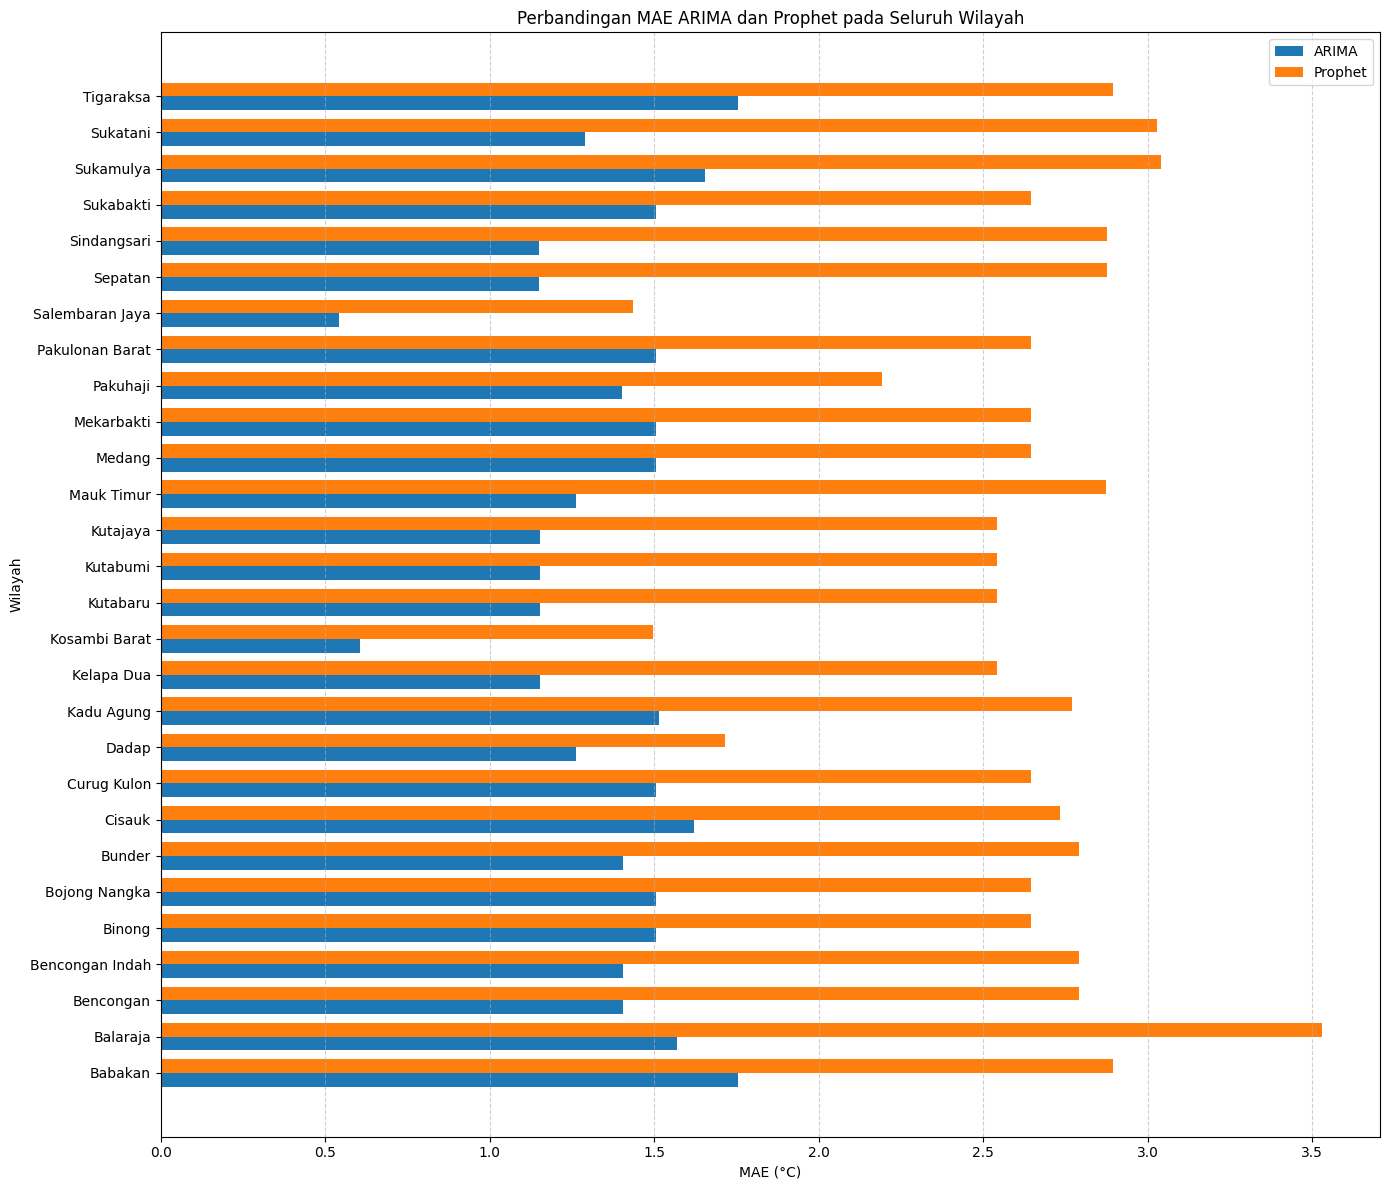

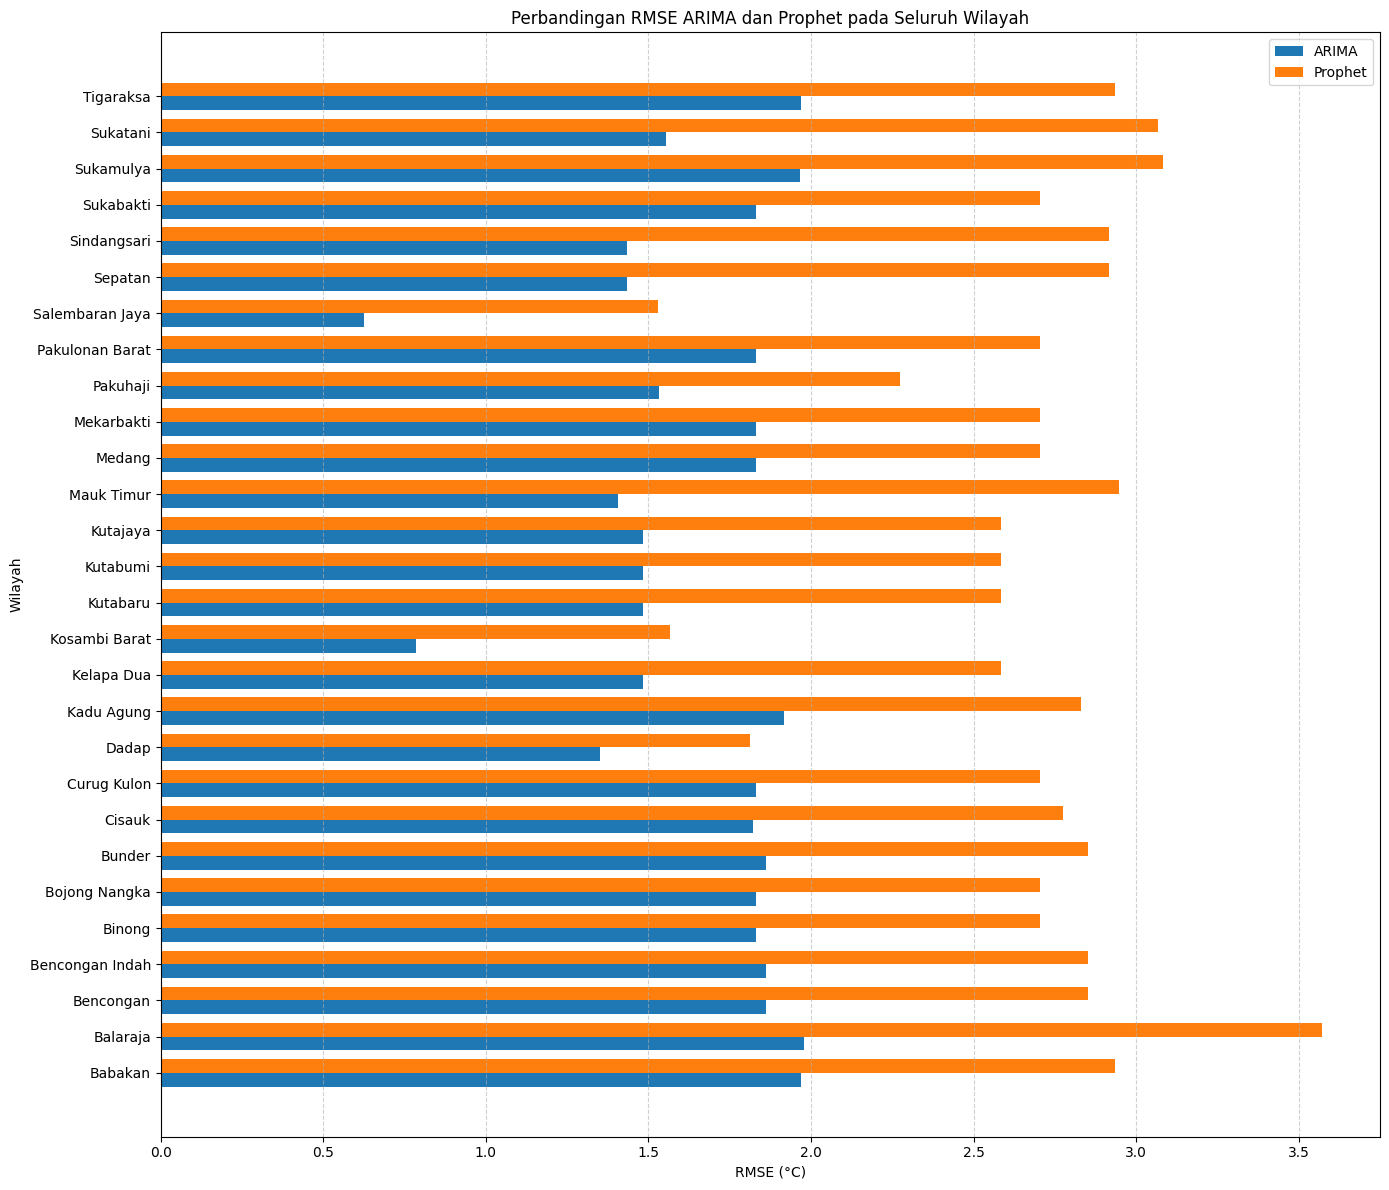

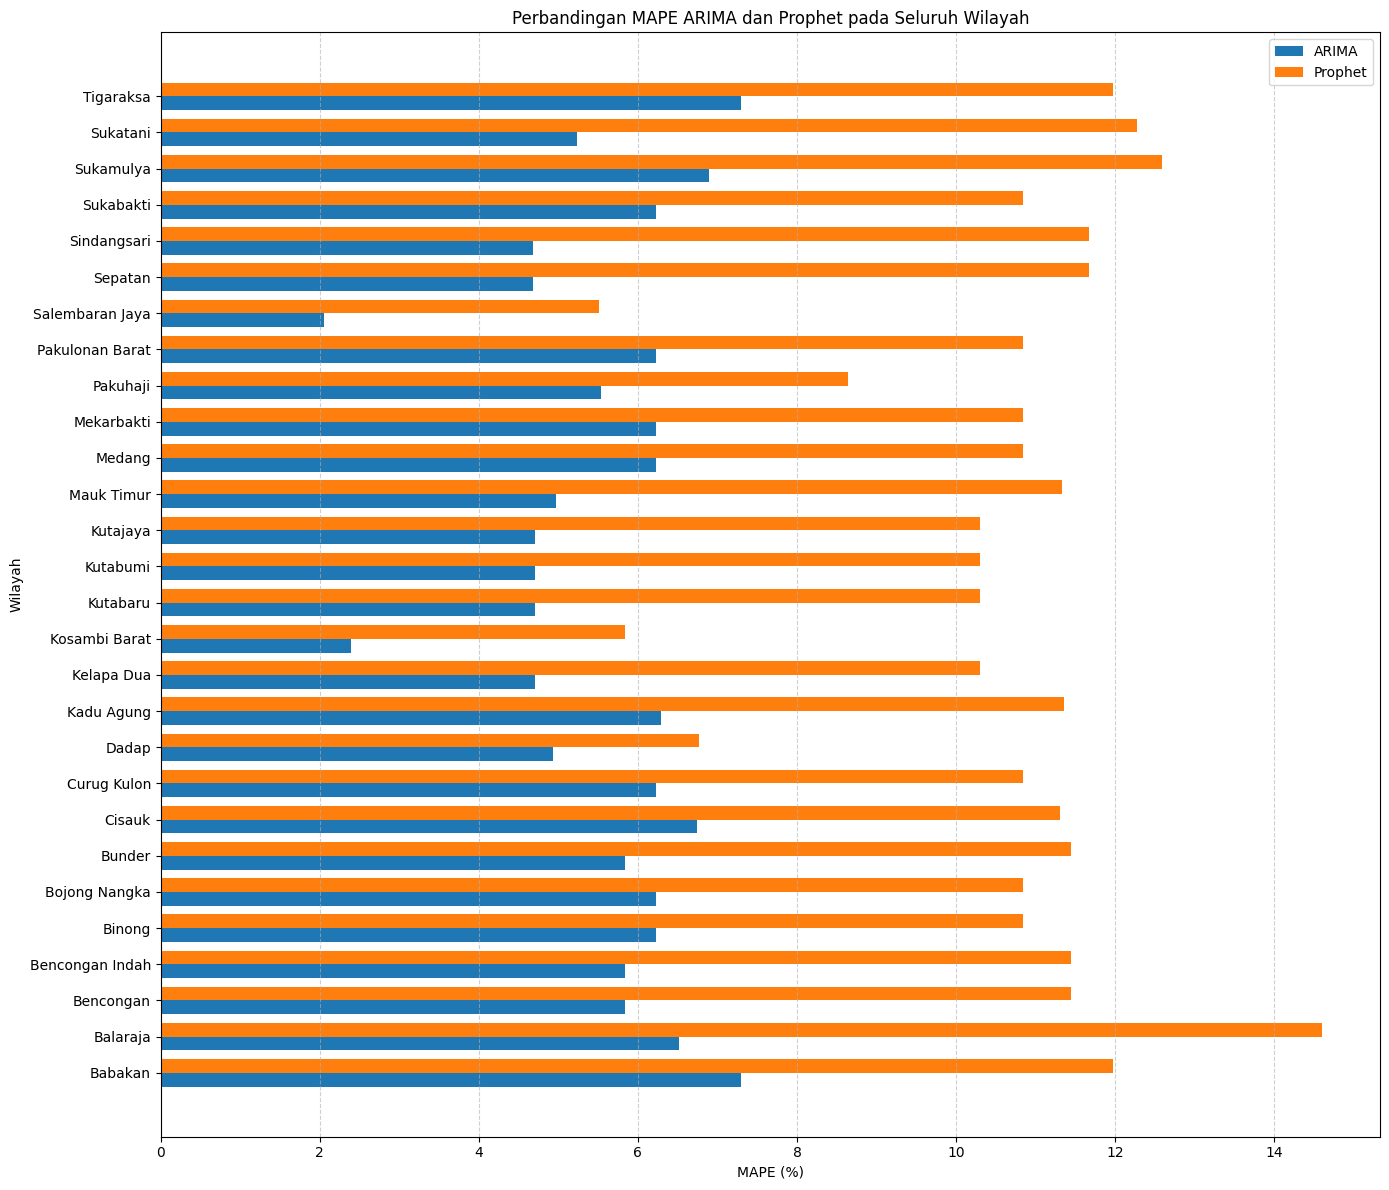

Ringkasan rata-rata nilai evaluasi:


Model,Rata-rata MAE,Rata-rata RMSE,Rata-rata MAPE (%)
ARIMA,1.3542,1.6448,5.5527
Prophet,2.6221,2.6777,10.6783



Visualisasi berhasil disimpan:


Grafik,Lokasi
Perbandingan MAE,/content/hasil_pemodelan/visualisasi/perbandingan_mae_seluruh_wilayah.png
Perbandingan RMSE,/content/hasil_pemodelan/visualisasi/perbandingan_rmse_seluruh_wilayah.png
Perbandingan MAPE,/content/hasil_pemodelan/visualisasi/perbandingan_mape_seluruh_wilayah.png


In [30]:
# =========================================
# BAGIAN 23
# VISUALISASI PERBANDINGAN KINERJA
# SELURUH WILAYAH
# =========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# MENYIAPKAN FOLDER VISUALISASI
# =========================================

folder_visualisasi = os.path.join(
    folder_hasil,
    "visualisasi"
)

os.makedirs(
    folder_visualisasi,
    exist_ok=True
)

# =========================================
# MEMERIKSA DATA EVALUASI
# =========================================

kolom_visualisasi = [
    "Wilayah",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen"
]

kolom_tidak_tersedia = [
    kolom
    for kolom in kolom_visualisasi
    if kolom not in tabel_evaluasi_wilayah.columns
]

if kolom_tidak_tersedia:

    raise ValueError(
        "Kolom berikut tidak tersedia: "
        f"{kolom_tidak_tersedia}"
    )

data_visualisasi = (
    tabel_evaluasi_wilayah[
        kolom_visualisasi
    ]
    .copy()
    .sort_values(
        by="Wilayah"
    )
    .reset_index(
        drop=True
    )
)

if len(data_visualisasi) != 28:

    raise ValueError(
        "Jumlah wilayah pada data "
        "visualisasi harus 28."
    )

# Posisi wilayah pada sumbu
posisi = np.arange(
    len(data_visualisasi)
)

tinggi_batang = 0.38

# =========================================
# VISUALISASI MAE
# =========================================

plt.figure(
    figsize=(14, 12)
)

plt.barh(
    posisi - tinggi_batang / 2,
    data_visualisasi["MAE_ARIMA"],
    height=tinggi_batang,
    label="ARIMA"
)

plt.barh(
    posisi + tinggi_batang / 2,
    data_visualisasi["MAE_Prophet"],
    height=tinggi_batang,
    label="Prophet"
)

plt.yticks(
    ticks=posisi,
    labels=data_visualisasi["Wilayah"]
)

plt.xlabel(
    "MAE (°C)"
)

plt.ylabel(
    "Wilayah"
)

plt.title(
    "Perbandingan MAE ARIMA dan Prophet "
    "pada Seluruh Wilayah"
)

plt.legend()
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

lokasi_grafik_mae = os.path.join(
    folder_visualisasi,
    "perbandingan_mae_seluruh_wilayah.png"
)

plt.savefig(
    lokasi_grafik_mae,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================
# VISUALISASI RMSE
# =========================================

plt.figure(
    figsize=(14, 12)
)

plt.barh(
    posisi - tinggi_batang / 2,
    data_visualisasi["RMSE_ARIMA"],
    height=tinggi_batang,
    label="ARIMA"
)

plt.barh(
    posisi + tinggi_batang / 2,
    data_visualisasi["RMSE_Prophet"],
    height=tinggi_batang,
    label="Prophet"
)

plt.yticks(
    ticks=posisi,
    labels=data_visualisasi["Wilayah"]
)

plt.xlabel(
    "RMSE (°C)"
)

plt.ylabel(
    "Wilayah"
)

plt.title(
    "Perbandingan RMSE ARIMA dan Prophet "
    "pada Seluruh Wilayah"
)

plt.legend()
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

lokasi_grafik_rmse = os.path.join(
    folder_visualisasi,
    "perbandingan_rmse_seluruh_wilayah.png"
)

plt.savefig(
    lokasi_grafik_rmse,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================
# VISUALISASI MAPE
# =========================================

plt.figure(
    figsize=(14, 12)
)

plt.barh(
    posisi - tinggi_batang / 2,
    data_visualisasi[
        "MAPE_ARIMA_Persen"
    ],
    height=tinggi_batang,
    label="ARIMA"
)

plt.barh(
    posisi + tinggi_batang / 2,
    data_visualisasi[
        "MAPE_Prophet_Persen"
    ],
    height=tinggi_batang,
    label="Prophet"
)

plt.yticks(
    ticks=posisi,
    labels=data_visualisasi["Wilayah"]
)

plt.xlabel(
    "MAPE (%)"
)

plt.ylabel(
    "Wilayah"
)

plt.title(
    "Perbandingan MAPE ARIMA dan Prophet "
    "pada Seluruh Wilayah"
)

plt.legend()
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

lokasi_grafik_mape = os.path.join(
    folder_visualisasi,
    "perbandingan_mape_seluruh_wilayah.png"
)

plt.savefig(
    lokasi_grafik_mape,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================
# RINGKASAN RATA-RATA NILAI EVALUASI
# =========================================

ringkasan_rata_rata = pd.DataFrame({
    "Model": [
        "ARIMA",
        "Prophet"
    ],
    "Rata-rata MAE": [
        data_visualisasi[
            "MAE_ARIMA"
        ].mean(),
        data_visualisasi[
            "MAE_Prophet"
        ].mean()
    ],
    "Rata-rata RMSE": [
        data_visualisasi[
            "RMSE_ARIMA"
        ].mean(),
        data_visualisasi[
            "RMSE_Prophet"
        ].mean()
    ],
    "Rata-rata MAPE (%)": [
        data_visualisasi[
            "MAPE_ARIMA_Persen"
        ].mean(),
        data_visualisasi[
            "MAPE_Prophet_Persen"
        ].mean()
    ]
})

kolom_rata_rata = [
    "Rata-rata MAE",
    "Rata-rata RMSE",
    "Rata-rata MAPE (%)"
]

ringkasan_rata_rata[
    kolom_rata_rata
] = ringkasan_rata_rata[
    kolom_rata_rata
].round(4)

print(
    "Ringkasan rata-rata nilai evaluasi:"
)

display(
    ringkasan_rata_rata
    .style
    .format({
        "Rata-rata MAE": "{:.4f}",
        "Rata-rata RMSE": "{:.4f}",
        "Rata-rata MAPE (%)": "{:.4f}"
    })
    .hide(
        axis="index"
    )
)

# =========================================
# MENAMPILKAN LOKASI BERKAS GRAFIK
# =========================================

daftar_grafik = pd.DataFrame({
    "Grafik": [
        "Perbandingan MAE",
        "Perbandingan RMSE",
        "Perbandingan MAPE"
    ],
    "Lokasi": [
        lokasi_grafik_mae,
        lokasi_grafik_rmse,
        lokasi_grafik_mape
    ]
})

print(
    "\nVisualisasi berhasil disimpan:"
)

display(
    daftar_grafik
    .style
    .set_properties(
        subset=[
            "Lokasi"
        ],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "500px"
        }
    )
    .hide(
        axis="index"
    )
)

# Bagian 24 — Pembentukan Kumpulan Data Dasbor

Tahap ini menggabungkan hasil prediksi dan evaluasi ARIMA serta Prophet ke dalam satu kumpulan data. Setiap baris memuat wilayah, waktu pengujian, suhu aktual, hasil prediksi, nilai kesalahan, model ARIMA terpilih, dan hasil evaluasi kedua metode. Nilai prediksi dibulatkan menjadi dua angka desimal, sedangkan nilai evaluasi dibulatkan menjadi empat angka desimal untuk kebutuhan penyajian. Kumpulan data akhir disimpan dalam format CSV agar dapat digunakan sebagai sumber data dasbor.

In [31]:
# =========================================
# BAGIAN 24
# PEMBENTUKAN KUMPULAN DATA DASBOR
# =========================================

import os
import numpy as np
import pandas as pd

# =========================================
# MENENTUKAN LOKASI PENYIMPANAN
# =========================================

lokasi_dataset_dashboard = os.path.join(
    folder_hasil,
    "dataset_dashboard_forecasting.csv"
)

# =========================================
# MEMERIKSA DATA SUMBER
# =========================================

kolom_prediksi_wajib = [
    "Wilayah",
    "ADM4",
    "Waktu",
    "suhu_data_uji",
    "Prediksi_ARIMA",
    "Prediksi_Prophet",
    "Error_Absolut_ARIMA",
    "Error_Absolut_Prophet"
]

kolom_evaluasi_wajib = [
    "Wilayah",
    "ADM4",
    "Jumlah_Data_Latih",
    "Jumlah_Data_Uji",
    "d_ARIMA",
    "Keterangan_ADF",
    "Model_ARIMA",
    "AIC_ARIMA",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen",
    "Pemenang_MAE",
    "Pemenang_RMSE",
    "Pemenang_MAPE",
    "Model_Unggul"
]

kolom_prediksi_tidak_tersedia = [
    kolom
    for kolom in kolom_prediksi_wajib
    if kolom not in df_prediksi_semua.columns
]

kolom_evaluasi_tidak_tersedia = [
    kolom
    for kolom in kolom_evaluasi_wajib
    if kolom not in df_evaluasi_semua.columns
]

if kolom_prediksi_tidak_tersedia:

    raise ValueError(
        "Kolom prediksi berikut tidak tersedia: "
        f"{kolom_prediksi_tidak_tersedia}"
    )

if kolom_evaluasi_tidak_tersedia:

    raise ValueError(
        "Kolom evaluasi berikut tidak tersedia: "
        f"{kolom_evaluasi_tidak_tersedia}"
    )

# =========================================
# MENYIAPKAN DATA PREDIKSI
# =========================================

data_prediksi_dashboard = (
    df_prediksi_semua[
        kolom_prediksi_wajib
    ]
    .copy()
)

data_prediksi_dashboard[
    "Waktu"
] = pd.to_datetime(
    data_prediksi_dashboard["Waktu"]
)

# =========================================
# MENYIAPKAN DATA EVALUASI
# =========================================

data_evaluasi_dashboard = (
    df_evaluasi_semua[
        kolom_evaluasi_wajib
    ]
    .copy()
)

# Memastikan setiap wilayah hanya memiliki
# satu baris hasil evaluasi
if data_evaluasi_dashboard[
    "Wilayah"
].duplicated().any():

    raise ValueError(
        "Terdapat wilayah yang memiliki "
        "lebih dari satu baris evaluasi."
    )

# =========================================
# MENGGABUNGKAN PREDIKSI DAN EVALUASI
# =========================================

dataset_dashboard = (
    data_prediksi_dashboard
    .merge(
        data_evaluasi_dashboard,
        on=[
            "Wilayah",
            "ADM4"
        ],
        how="left",
        validate="many_to_one"
    )
)

# =========================================
# MENAMBAHKAN ATRIBUT WAKTU
# =========================================

dataset_dashboard[
    "Tanggal"
] = dataset_dashboard[
    "Waktu"
].dt.date

dataset_dashboard[
    "Jam"
] = dataset_dashboard[
    "Waktu"
].dt.strftime(
    "%H:%M"
)

dataset_dashboard[
    "Periode_Data"
] = "Data Uji"

# =========================================
# MENYESUAIKAN LABEL MODEL ARIMA
# =========================================

dataset_dashboard[
    "Model_ARIMA"
] = dataset_dashboard[
    "Model_ARIMA"
].astype(str).apply(
    lambda nilai: (
        nilai
        if nilai.startswith("ARIMA")
        else f"ARIMA{nilai}"
    )
)

# =========================================
# MENENTUKAN MODEL TERDEKAT
# PADA SETIAP WAKTU
# =========================================

dataset_dashboard[
    "Model_Prediksi_Terdekat"
] = np.where(
    dataset_dashboard[
        "Error_Absolut_ARIMA"
    ]
    <= dataset_dashboard[
        "Error_Absolut_Prophet"
    ],
    "ARIMA",
    "Prophet"
)

dataset_dashboard[
    "Error_Absolut_Terendah"
] = dataset_dashboard[
    [
        "Error_Absolut_ARIMA",
        "Error_Absolut_Prophet"
    ]
].min(
    axis=1
)

# Selisih positif menunjukkan bahwa
# kesalahan Prophet lebih besar
dataset_dashboard[
    "Selisih_Error_Prophet_ARIMA"
] = (
    dataset_dashboard[
        "Error_Absolut_Prophet"
    ]
    - dataset_dashboard[
        "Error_Absolut_ARIMA"
    ]
)

# =========================================
# MEMBULATKAN NILAI UNTUK PENYAJIAN
# =========================================

# Suhu aktual berasal dari data bilangan bulat
dataset_dashboard[
    "suhu_data_uji"
] = (
    dataset_dashboard[
        "suhu_data_uji"
    ]
    .round(0)
    .astype(int)
)

# Prediksi dan kesalahan per waktu
# ditampilkan dengan dua angka desimal
kolom_dua_desimal = [
    "Prediksi_ARIMA",
    "Prediksi_Prophet",
    "Error_Absolut_ARIMA",
    "Error_Absolut_Prophet",
    "Error_Absolut_Terendah",
    "Selisih_Error_Prophet_ARIMA"
]

dataset_dashboard[
    kolom_dua_desimal
] = dataset_dashboard[
    kolom_dua_desimal
].round(2)

# Nilai evaluasi ditampilkan dengan
# empat angka desimal
kolom_empat_desimal = [
    "AIC_ARIMA",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen"
]

dataset_dashboard[
    kolom_empat_desimal
] = dataset_dashboard[
    kolom_empat_desimal
].round(4)

# =========================================
# MENGATUR URUTAN KOLOM
# =========================================

urutan_kolom_dashboard = [
    "Wilayah",
    "ADM4",
    "Waktu",
    "Tanggal",
    "Jam",
    "Periode_Data",
    "suhu_data_uji",
    "Prediksi_ARIMA",
    "Prediksi_Prophet",
    "Error_Absolut_ARIMA",
    "Error_Absolut_Prophet",
    "Error_Absolut_Terendah",
    "Selisih_Error_Prophet_ARIMA",
    "Model_Prediksi_Terdekat",
    "d_ARIMA",
    "Keterangan_ADF",
    "Model_ARIMA",
    "AIC_ARIMA",
    "Jumlah_Data_Latih",
    "Jumlah_Data_Uji",
    "MAE_ARIMA",
    "RMSE_ARIMA",
    "MAPE_ARIMA_Persen",
    "MAE_Prophet",
    "RMSE_Prophet",
    "MAPE_Prophet_Persen",
    "Pemenang_MAE",
    "Pemenang_RMSE",
    "Pemenang_MAPE",
    "Model_Unggul"
]

dataset_dashboard = (
    dataset_dashboard[
        urutan_kolom_dashboard
    ]
    .sort_values(
        by=[
            "Wilayah",
            "Waktu"
        ]
    )
    .reset_index(
        drop=True
    )
)

# =========================================
# VALIDASI DATASET DASBOR
# =========================================

jumlah_wilayah_dashboard = (
    dataset_dashboard[
        "Wilayah"
    ].nunique()
)

jumlah_baris_dashboard = len(
    dataset_dashboard
)

jumlah_waktu_per_wilayah = (
    dataset_dashboard
    .groupby(
        "Wilayah"
    )
    .size()
)

if jumlah_wilayah_dashboard != 28:

    raise ValueError(
        "Jumlah wilayah pada dataset dasbor "
        f"adalah {jumlah_wilayah_dashboard}, "
        "seharusnya 28."
    )

if jumlah_baris_dashboard != 112:

    raise ValueError(
        "Jumlah baris dataset dasbor "
        f"adalah {jumlah_baris_dashboard}, "
        "seharusnya 112."
    )

if not (
    jumlah_waktu_per_wilayah == 4
).all():

    raise ValueError(
        "Terdapat wilayah yang tidak memiliki "
        "empat waktu pengujian."
    )

if dataset_dashboard.isna().any().any():

    kolom_kosong = (
        dataset_dashboard
        .columns[
            dataset_dashboard
            .isna()
            .any()
        ]
        .tolist()
    )

    raise ValueError(
        "Terdapat nilai kosong pada kolom: "
        f"{kolom_kosong}"
    )

if dataset_dashboard[
    [
        "Wilayah",
        "Waktu"
    ]
].duplicated().any():

    raise ValueError(
        "Terdapat kombinasi wilayah dan waktu "
        "yang tercatat lebih dari satu kali."
    )

# =========================================
# MENYIMPAN DATASET DASBOR
# =========================================

dataset_dashboard.to_csv(
    lokasi_dataset_dashboard,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

if not os.path.exists(
    lokasi_dataset_dashboard
):

    raise FileNotFoundError(
        "Dataset dasbor gagal disimpan."
    )

# =========================================
# MENAMPILKAN RINGKASAN HASIL
# =========================================

ringkasan_dataset_dashboard = pd.DataFrame({
    "Pemeriksaan": [
        "Jumlah wilayah",
        "Jumlah baris",
        "Jumlah waktu per wilayah",
        "Nilai kosong",
        "Data wilayah dan waktu ganda",
        "Lokasi berkas"
    ],
    "Hasil": [
        jumlah_wilayah_dashboard,
        jumlah_baris_dashboard,
        4,
        "Tidak ada",
        "Tidak ada",
        lokasi_dataset_dashboard
    ],
    "Status": [
        "Sesuai",
        "Sesuai",
        "Sesuai",
        "Sesuai",
        "Sesuai",
        "Berhasil"
    ]
})

print(
    "Pembentukan dataset dasbor berhasil:"
)

display(
    ringkasan_dataset_dashboard
    .style
    .set_properties(
        subset=[
            "Hasil"
        ],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "400px"
        }
    )
    .hide(
        axis="index"
    )
)

print(
    "\n5 data pertama dataset dasbor:"
)

display(
    dataset_dashboard.head()
)

print(
    "\nNama berkas:"
)

print(
    os.path.basename(
        lokasi_dataset_dashboard
    )
)

print(
    "Lokasi:"
)

print(
    lokasi_dataset_dashboard
)

Pembentukan dataset dasbor berhasil:


Pemeriksaan,Hasil,Status
Jumlah wilayah,28,Sesuai
Jumlah baris,112,Sesuai
Jumlah waktu per wilayah,4,Sesuai
Nilai kosong,Tidak ada,Sesuai
Data wilayah dan waktu ganda,Tidak ada,Sesuai
Lokasi berkas,/content/hasil_pemodelan/dataset_dashboard_forecasting.csv,Berhasil



5 data pertama dataset dasbor:


,Wilayah,ADM4,Waktu,Tanggal,Jam,Periode_Data,suhu_data_uji,Prediksi_ARIMA,Prediksi_Prophet,Error_Absolut_ARIMA,...,MAE_ARIMA,RMSE_ARIMA,MAPE_ARIMA_Persen,MAE_Prophet,RMSE_Prophet,MAPE_Prophet_Persen,Pemenang_MAE,Pemenang_RMSE,Pemenang_MAPE,Model_Unggul
0,Babakan,36.03.20.1011,2026-05-25 21:00:00,2026-05-25,21:00,Data Uji,25,25.43,27.05,0.43,...,1.7556,1.9693,7.2972,2.8944,2.9357,11.9746,ARIMA,ARIMA,ARIMA,ARIMA
1,Babakan,36.03.20.1011,2026-05-26 00:00:00,2026-05-26,00:00,Data Uji,24,25.56,27.11,1.56,...,1.7556,1.9693,7.2972,2.8944,2.9357,11.9746,ARIMA,ARIMA,ARIMA,ARIMA
2,Babakan,36.03.20.1011,2026-05-26 03:00:00,2026-05-26,03:00,Data Uji,24,26.19,27.18,2.19,...,1.7556,1.9693,7.2972,2.8944,2.9357,11.9746,ARIMA,ARIMA,ARIMA,ARIMA
3,Babakan,36.03.20.1011,2026-05-26 06:00:00,2026-05-26,06:00,Data Uji,24,26.85,27.24,2.85,...,1.7556,1.9693,7.2972,2.8944,2.9357,11.9746,ARIMA,ARIMA,ARIMA,ARIMA
4,Balaraja,36.03.01.1001,2026-05-25 21:00:00,2026-05-25,21:00,Data Uji,25,24.54,27.61,0.46,...,1.5696,1.9779,6.5210,3.5302,3.5709,14.6005,ARIMA,ARIMA,ARIMA,ARIMA



Nama berkas:
dataset_dashboard_forecasting.csv
Lokasi:
/content/hasil_pemodelan/dataset_dashboard_forecasting.csv


In [32]:
# =========================================
# PEMERIKSAAN AKHIR DATASET DASBOR
# =========================================

print(
    "Ukuran dataset:",
    dataset_dashboard.shape
)

print(
    "Jumlah wilayah:",
    dataset_dashboard[
        "Wilayah"
    ].nunique()
)

print(
    "Jumlah baris setiap wilayah:"
)

display(
    dataset_dashboard
    .groupby(
        "Wilayah"
    )
    .size()
    .reset_index(
        name="Jumlah_Baris"
    )
)

print(
    "Tipe data ADM4:",
    dataset_dashboard[
        "ADM4"
    ].dtype
)

Ukuran dataset: (112, 30)
Jumlah wilayah: 28
Jumlah baris setiap wilayah:


,Wilayah,Jumlah_Baris
0,Babakan,4
1,Balaraja,4
2,Bencongan,4
3,Bencongan Indah,4
4,Binong,4
5,Bojong Nangka,4
6,Bunder,4
7,Cisauk,4
8,Curug Kulon,4
9,Dadap,4


Tipe data ADM4: object
